In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv(
    r"E:\Visualization\Visualization\Visualization\Data\learnx_realistic_500k.csv"
)
print(f"Số lượng bản ghi: {df.shape[0]:,}")
print(f"Số lượng thuộc tính: {df.shape[1]}")
print("5 dòng đầu tiên:")
df.head()

Số lượng bản ghi: 501,000
Số lượng thuộc tính: 20
5 dòng đầu tiên:


,user_id,age,country,major,signup_days_ago,sessions_per_week,avg_session_minutes,videos_watched,quizzes_taken,forum_posts,completion_rate,courses_enrolled,assignments_submitted,premium_purchased,total_spent_usd,discount_used,ai_recommend_click,ai_recommend_enroll,churn_risk,future_purchase
0,1,21,USA,Design,135,3,66.0,27,7,13.0,0.86,4,3,0,NaN,3,8.0,0,0,1
1,2,28,India,Business,303,10,29.0,7,28,5.0,0.29,17,10,0,65.0,3,6.0,1,0,0
2,3,24,India,Computer Science,182,1,77.0,7,17,6.0,0.60,2,1,0,20.0,7,3.0,0,0,0
3,4,23,Singapore,Engineering,267,7,61.0,45,3,8.0,0.33,9,10,0,30.0,0,5.0,0,1,0
4,5,20,Canada,Finance,208,3,21.0,49,3,3.0,0.17,12,12,0,10.0,7,8.0,1,0,1


In [52]:
import os
print(os.getcwd())

e:\Visualization\Visualization\Visualization\Lab_main\Code


In [53]:
for col in ["country", "major"]:
    print(f"{col}")
    print(f"Số giá trị duy nhất: {df[col].nunique()}")
    print(df[col].value_counts())

country
Số giá trị duy nhất: 8
country
Vietnam      140072
India        110171
USA           90179
Canada        40298
UK            40103
Germany       29939
Singapore     25362
Australia     24876
Name: count, dtype: int64
major
Số giá trị duy nhất: 8
major
Computer Science    125437
Engineering          90306
Business             75641
Data Science         60052
Marketing            50004
Design               39912
Finance              34646
Cyber Security       25002
Name: count, dtype: int64


# 2. Làm sạch dữ liệu


In [54]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Số lượng thiếu": missing, "Tỷ lệ (%)": missing_pct})
missing_df = missing_df[missing_df["Số lượng thiếu"] > 0].sort_values(
    "Tỷ lệ (%)", ascending=False
)
print("CÁC CỘT CÓ DỮ LIỆU THIẾU:")
print(missing_df)
print(f"Tổng số ô thiếu: {df.isnull().sum().sum():,}")

CÁC CỘT CÓ DỮ LIỆU THIẾU:
                     Số lượng thiếu  Tỷ lệ (%)
total_spent_usd               19867       3.97
avg_session_minutes           14912       2.98
ai_recommend_click            14842       2.96
forum_posts                   10101       2.02
completion_rate               10018       2.00
Tổng số ô thiếu: 69,740


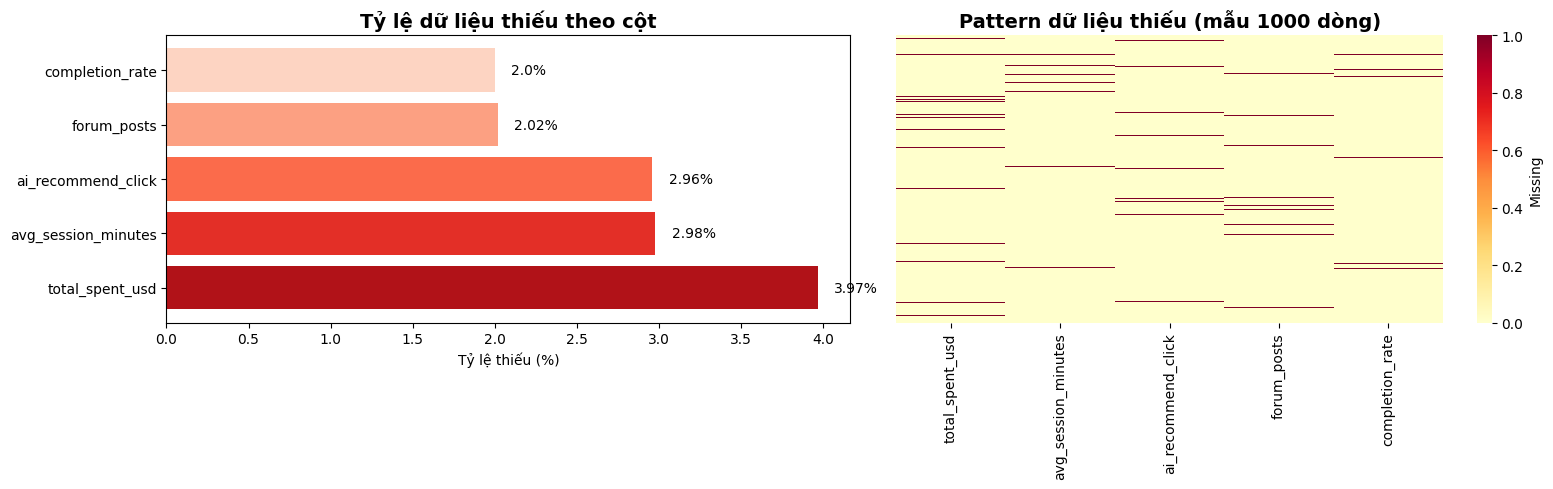

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
missing_cols = missing_df.index.tolist()
colors = sns.color_palette("Reds_r", len(missing_cols))
axes[0].barh(missing_cols, missing_df["Tỷ lệ (%)"], color=colors)
axes[0].set_xlabel("Tỷ lệ thiếu (%)")
axes[0].set_title("Tỷ lệ dữ liệu thiếu theo cột", fontsize=14, fontweight="bold")
for i, v in enumerate(missing_df["Tỷ lệ (%)"]):
    axes[0].text(v + 0.1, i, f"{v}%", va="center")

# Heatmap
sample = df[missing_cols].sample(1000, random_state=42)
sns.heatmap(
    sample.isnull(),
    cbar=True,
    yticklabels=False,
    ax=axes[1],
    cmap="YlOrRd",
    cbar_kws={"label": "Missing"},
)
axes[1].set_title(
    "Pattern dữ liệu thiếu (mẫu 1000 dòng)", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [56]:
print("TRƯỚC KHI XỬ LÝ:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()

cols_fill_median = [
    "avg_session_minutes",
    "forum_posts",
    "completion_rate",
    "total_spent_usd",
    "discount_used",
    "ai_recommend_click",
]

for col in cols_fill_median:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"  {col}: điền median = {median_val}")

print("SAU KHI XỬ LÝ:")
print(f"Tổng missing còn lại: {df.isnull().sum().sum()}")

TRƯỚC KHI XỬ LÝ:
avg_session_minutes    14912
forum_posts            10101
completion_rate        10018
total_spent_usd        19867
ai_recommend_click     14842
dtype: int64

  avg_session_minutes: điền median = 33.0
  forum_posts: điền median = 5.0
  completion_rate: điền median = 0.36
  total_spent_usd: điền median = 30.0
  discount_used: điền median = 4.0
  ai_recommend_click: điền median = 7.0
SAU KHI XỬ LÝ:
Tổng missing còn lại: 0


# 2.1 . XỬ LÝ GIÁ TRỊ BẤT THƯỜNG


In [57]:
print("KIỂM TRA GIÁ TRỊ BẤT THƯỜNG:")

print(f"age: min={df['age'].min()}, max={df['age'].max()}")
print(f"Giá trị ngoài [16, 40] : {((df['age'] < 16) | (df['age'] > 40)).sum()}")

print(
    f"completion_rate: min={df['completion_rate'].min()}, max={df['completion_rate'].max()}"
)
print(
    f"Giá trị ngoài [0, 1] : {((df['completion_rate'] < 0) | (df['completion_rate'] > 1)).sum()}"
)

print(
    f"sessions_per_week: min={df['sessions_per_week'].min()}, max={df['sessions_per_week'].max()}"
)
print(f"Giá trị âm : {(df['sessions_per_week'] < 0).sum()}")

print(
    f"total_spent_usd: min={df['total_spent_usd'].min()}, max={df['total_spent_usd'].max()}"
)
print(f"Giá trị âm : {(df['total_spent_usd'] < 0).sum()}")

for col in ["premium_purchased", "churn_risk", "future_purchase"]:
    print(f"{col}: unique : {sorted(df[col].unique())}")

KIỂM TRA GIÁ TRỊ BẤT THƯỜNG:
age: min=17, max=35
Giá trị ngoài [16, 40] : 0
completion_rate: min=0.0, max=1.2
Giá trị ngoài [0, 1] : 15
sessions_per_week: min=0, max=17
Giá trị âm : 0
total_spent_usd: min=-10.0, max=350.0
Giá trị âm : 10
premium_purchased: unique : [np.int64(0), np.int64(1)]
churn_risk: unique : [np.int64(0), np.int64(1)]
future_purchase: unique : [np.int64(0), np.int64(1)]


In [58]:
print("XỬ LÝ GIÁ TRỊ BẤT THƯỜNG:")

df["age"] = df["age"].clip(lower=16, upper=45)
print("Đưa age về [16, 45]")

df["completion_rate"] = df["completion_rate"].clip(lower=0, upper=1)
print("Đưa completion_rate về [0, 1]")

df["sessions_per_week"] = df["sessions_per_week"].clip(lower=0)
print("Đảm bảo sessions_per_week >= 0")

df["total_spent_usd"] = df["total_spent_usd"].clip(lower=0)
print("Đảm bảo total_spent_usd >= 0")

XỬ LÝ GIÁ TRỊ BẤT THƯỜNG:
Đưa age về [16, 45]
Đưa completion_rate về [0, 1]
Đảm bảo sessions_per_week >= 0
Đảm bảo total_spent_usd >= 0


# 2.2 . Kiểm tra trùng lặp


In [59]:
dup_all = df.duplicated().sum()
print(f"Số dòng trùng lặp hoàn toàn: {dup_all:,}")

dup_id = df.duplicated(subset=["user_id"]).sum()
print(f"Số dòng trùng user_id: {dup_id:,}")

if dup_id > 0:
    print(f"Có {dup_id:,} bản ghi trùng user_id.")
    df = df.drop_duplicates(subset=["user_id"], keep="first")
    print(f"Sau xử lý: {df.shape[0]:,} bản ghi")
else:
    print(" Không có dữ liệu trùng lặp.")

print(f"Kích thước dữ liệu sau làm sạch: {df.shape}")

Số dòng trùng lặp hoàn toàn: 1,000
Số dòng trùng user_id: 1,000
Có 1,000 bản ghi trùng user_id.
Sau xử lý: 500,000 bản ghi
Kích thước dữ liệu sau làm sạch: (500000, 20)


# 3. Phân tích bằng biểu đồ

# Phân phối thời gian học gần như đồng đều, cho thấy sự đa dạng trong thói quen học.

# Median và Mean gần nhau → phân phối khá cân đối

# Người dùng Premium có xu hướng học lâu hơn so với Free users


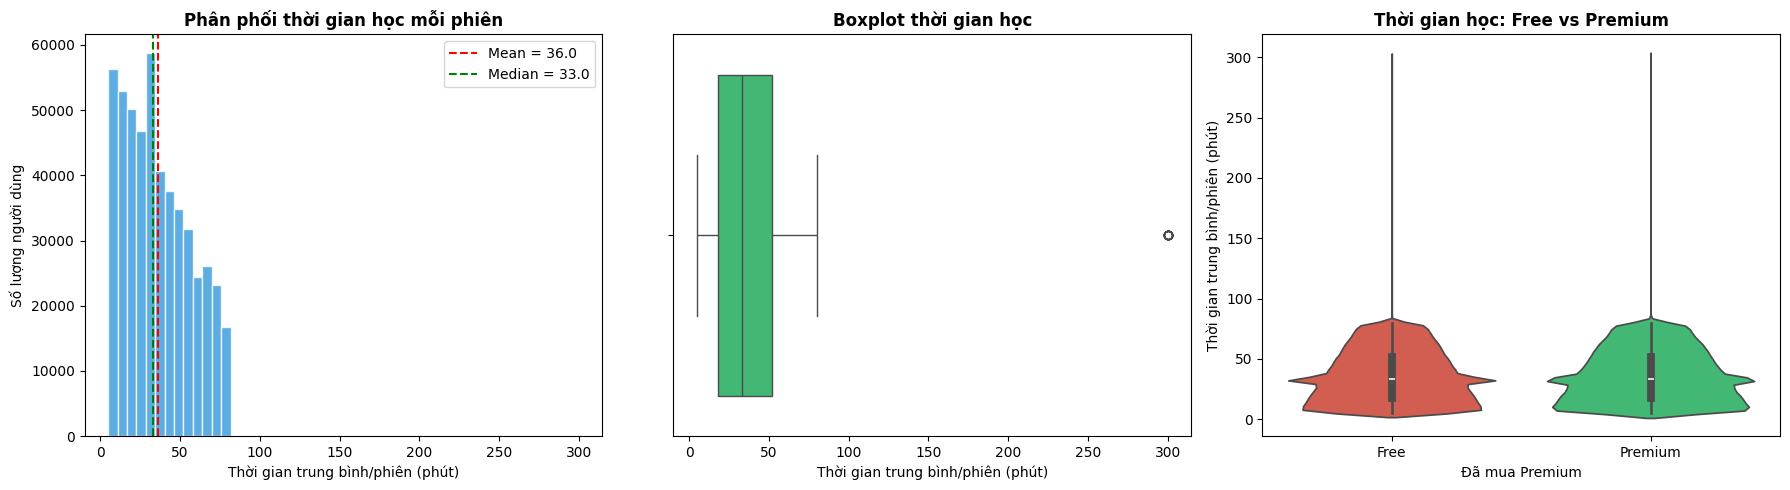

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(
    df["avg_session_minutes"], bins=50, color="#3498db", edgecolor="white", alpha=0.8
)
axes[0].axvline(
    df["avg_session_minutes"].mean(),
    color="red",
    linestyle="--",
    label=f'Mean = {df["avg_session_minutes"].mean():.1f}',
)
axes[0].axvline(
    df["avg_session_minutes"].median(),
    color="green",
    linestyle="--",
    label=f'Median = {df["avg_session_minutes"].median():.1f}',
)
axes[0].set_xlabel("Thời gian trung bình/phiên (phút)")
axes[0].set_ylabel("Số lượng người dùng")
axes[0].set_title("Phân phối thời gian học mỗi phiên", fontweight="bold")
axes[0].legend()

# Boxplot
sns.boxplot(x=df["avg_session_minutes"], ax=axes[1], color="#2ecc71")
axes[1].set_xlabel("Thời gian trung bình/phiên (phút)")
axes[1].set_title("Boxplot thời gian học", fontweight="bold")

# Violin theo Premium
sns.violinplot(
    x="premium_purchased",
    y="avg_session_minutes",
    data=df,
    ax=axes[2],
    palette=["#e74c3c", "#2ecc71"],
)
axes[2].set_xlabel("Đã mua Premium")
axes[2].set_ylabel("Thời gian trung bình/phiên (phút)")
axes[2].set_title("Thời gian học: Free vs Premium", fontweight="bold")
axes[2].set_xticklabels(["Free", "Premium"])

plt.tight_layout()
plt.show()

In [61]:
print(f"Thống kê avg_session_minutes:")
print(df["avg_session_minutes"].describe().round(2))

Thống kê avg_session_minutes:
count    500000.00
mean         36.03
std          20.74
min           5.00
25%          18.00
50%          33.00
75%          52.00
max         300.00
Name: avg_session_minutes, dtype: float64


# 3.1 Số lần truy cập mỗi tuần

# Đa số người dùng truy cập 1-5 lần/tuần

# Có một nhóm nhỏ power users truy cập >10 lần/tuần

# Không có sự khác biệt lớn giữa các quốc gia và ngành học"


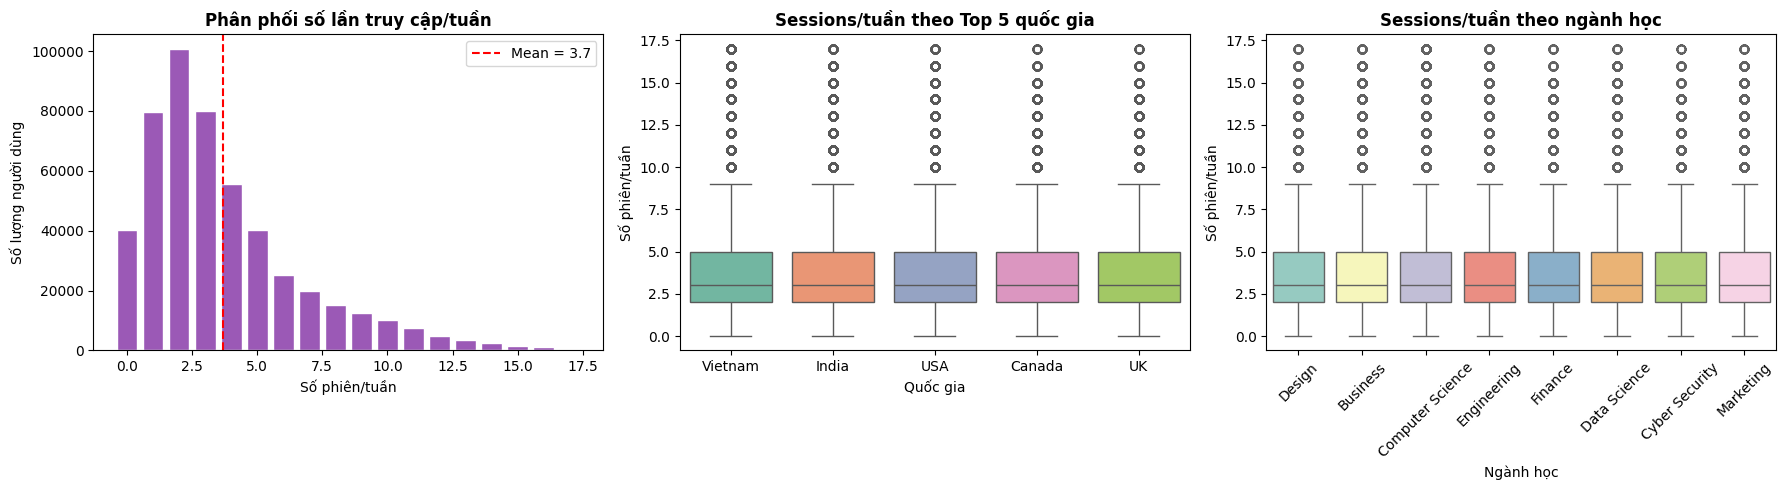

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
session_counts = df["sessions_per_week"].value_counts().sort_index()
axes[0].bar(
    session_counts.index, session_counts.values, color="#9b59b6", edgecolor="white"
)
axes[0].set_xlabel("Số phiên/tuần")
axes[0].set_ylabel("Số lượng người dùng")
axes[0].set_title("Phân phối số lần truy cập/tuần", fontweight="bold")
axes[0].axvline(
    df["sessions_per_week"].mean(),
    color="red",
    linestyle="--",
    label=f'Mean = {df["sessions_per_week"].mean():.1f}',
)
axes[0].legend()

# Theo quốc gia (Top 5)
top_countries = df["country"].value_counts().head(5).index
df_top = df[df["country"].isin(top_countries)]
sns.boxplot(
    x="country",
    y="sessions_per_week",
    data=df_top,
    ax=axes[1],
    palette="Set2",
    order=top_countries,
)
axes[1].set_xlabel("Quốc gia")
axes[1].set_ylabel("Số phiên/tuần")
axes[1].set_title("Sessions/tuần theo Top 5 quốc gia", fontweight="bold")

# Theo ngành học
sns.boxplot(x="major", y="sessions_per_week", data=df, ax=axes[2], palette="Set3")
axes[2].set_xlabel("Ngành học")
axes[2].set_ylabel("Số phiên/tuần")
axes[2].set_title("Sessions/tuần theo ngành học", fontweight="bold")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 3.2. Mức độ hoàn thành khóa học (completion rate)

# Phân phối completion rate khá đồng đều, nhưng có nhiều người dùng ở mức thấp (<20%)

# Người có nguy cơ churn có completion rate rõ ràng thấp hơn

# Không có sự khác biệt lớn giữa các ngành học

# Chi tiêu không tỷ lệ thuận rõ ràng với completion rate"


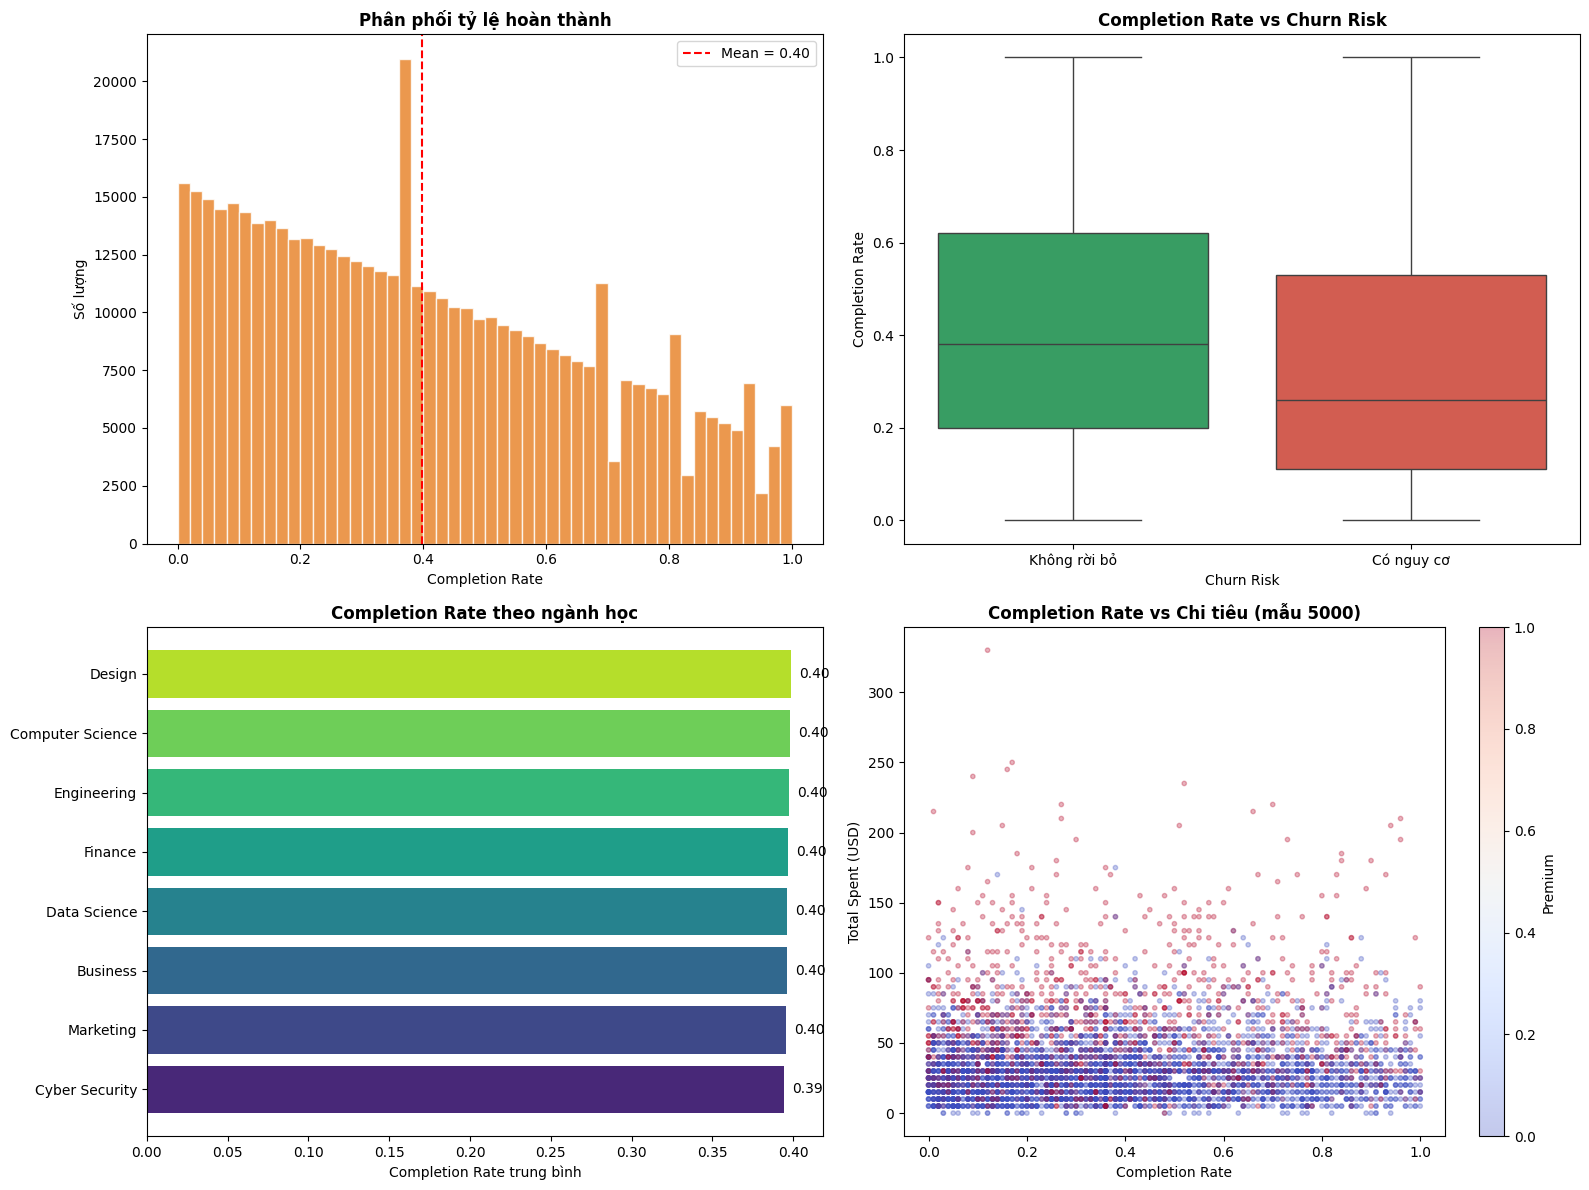

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
axes[0, 0].hist(
    df["completion_rate"], bins=50, color="#e67e22", edgecolor="white", alpha=0.8
)
axes[0, 0].axvline(
    df["completion_rate"].mean(),
    color="red",
    linestyle="--",
    label=f'Mean = {df["completion_rate"].mean():.2f}',
)
axes[0, 0].set_xlabel("Completion Rate")
axes[0, 0].set_ylabel("Số lượng")
axes[0, 0].set_title("Phân phối tỷ lệ hoàn thành", fontweight="bold")
axes[0, 0].legend()

# Completion rate theo churn_risk
sns.boxplot(
    x="churn_risk",
    y="completion_rate",
    data=df,
    ax=axes[0, 1],
    palette=["#27ae60", "#e74c3c"],
)
axes[0, 1].set_xlabel("Churn Risk")
axes[0, 1].set_ylabel("Completion Rate")
axes[0, 1].set_title("Completion Rate vs Churn Risk", fontweight="bold")
axes[0, 1].set_xticklabels(["Không rời bỏ", "Có nguy cơ"])

# Theo major
major_completion = (
    df.groupby("major")["completion_rate"].mean().sort_values(ascending=True)
)
axes[1, 0].barh(
    major_completion.index,
    major_completion.values,
    color=sns.color_palette("viridis", len(major_completion)),
)
axes[1, 0].set_xlabel("Completion Rate trung bình")
axes[1, 0].set_title("Completion Rate theo ngành học", fontweight="bold")
for i, v in enumerate(major_completion.values):
    axes[1, 0].text(v + 0.005, i, f"{v:.2f}", va="center")

# Scatter: completion_rate vs total_spent_usd
sample_plot = df.sample(5000, random_state=42)
scatter = axes[1, 1].scatter(
    sample_plot["completion_rate"],
    sample_plot["total_spent_usd"],
    c=sample_plot["premium_purchased"],
    cmap="coolwarm",
    alpha=0.3,
    s=10,
)
axes[1, 1].set_xlabel("Completion Rate")
axes[1, 1].set_ylabel("Total Spent (USD)")
axes[1, 1].set_title("Completion Rate vs Chi tiêu (mẫu 5000)", fontweight="bold")
plt.colorbar(scatter, ax=axes[1, 1], label="Premium")

plt.tight_layout()
plt.show()

In [64]:
bins = [0, 0.2, 0.5, 0.8, 1.0]
labels = ["Rất thấp (<20%)", "Thấp (20-50%)", "Trung bình (50-80%)", "Cao (>80%)"]
df["completion_group"] = pd.cut(
    df["completion_rate"], bins=bins, labels=labels, include_lowest=True
)
print("Phân bố nhóm completion rate:")
print(df["completion_group"].value_counts().sort_index())

Phân bố nhóm completion rate:
completion_group
Rất thấp (<20%)        150675
Thấp (20-50%)          181133
Trung bình (50-80%)    118514
Cao (>80%)              49678
Name: count, dtype: int64


# 3.3 Xu hướng học theo thời gian"

# Người dùng mới (0-30 ngày) có sessions/tuần và completion rate ổn định

# Không có sự suy giảm rõ rệt theo thời gian → retention tương đối ổn

# Tỷ lệ churn có thể tăng nhẹ ở các cohort cũ hơn

# Videos watched khá đồng đều giữa các cohort"


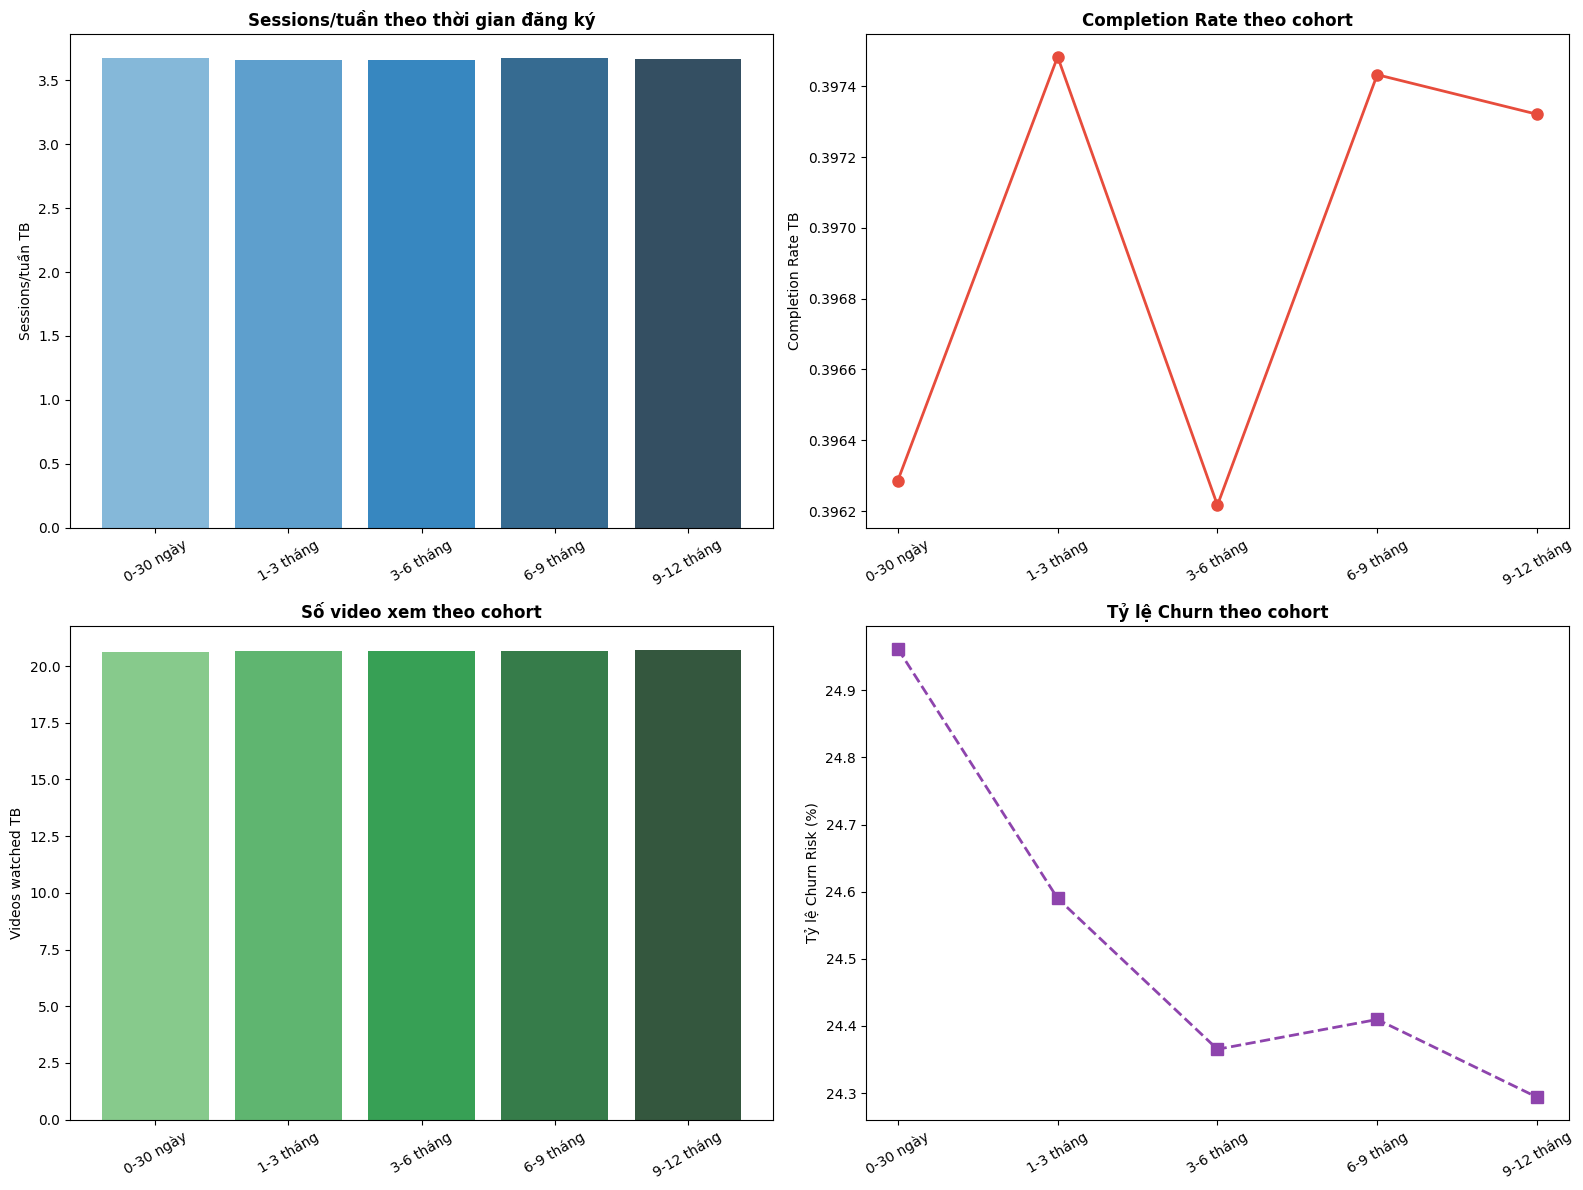

In [65]:
ig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Phân nhóm theo thời gian đăng ký
df["signup_period"] = pd.cut(
    df["signup_days_ago"],
    bins=[0, 30, 90, 180, 270, 365],
    labels=["0-30 ngày", "1-3 tháng", "3-6 tháng", "6-9 tháng", "9-12 tháng"],
)

# Số phiên/tuần theo cohort
cohort_sessions = df.groupby("signup_period")["sessions_per_week"].mean()
axes[0, 0].bar(
    range(len(cohort_sessions)),
    cohort_sessions.values,
    color=sns.color_palette("Blues_d", len(cohort_sessions)),
)
axes[0, 0].set_xticks(range(len(cohort_sessions)))
axes[0, 0].set_xticklabels(cohort_sessions.index, rotation=30)
axes[0, 0].set_ylabel("Sessions/tuần TB")
axes[0, 0].set_title("Sessions/tuần theo thời gian đăng ký", fontweight="bold")

# Completion rate theo cohort
cohort_completion = df.groupby("signup_period")["completion_rate"].mean()
axes[0, 1].plot(
    range(len(cohort_completion)),
    cohort_completion.values,
    "o-",
    color="#e74c3c",
    linewidth=2,
    markersize=8,
)
axes[0, 1].set_xticks(range(len(cohort_completion)))
axes[0, 1].set_xticklabels(cohort_completion.index, rotation=30)
axes[0, 1].set_ylabel("Completion Rate TB")
axes[0, 1].set_title("Completion Rate theo cohort", fontweight="bold")

# Videos watched theo cohort
cohort_videos = df.groupby("signup_period")["videos_watched"].mean()
axes[1, 0].bar(
    range(len(cohort_videos)),
    cohort_videos.values,
    color=sns.color_palette("Greens_d", len(cohort_videos)),
)
axes[1, 0].set_xticks(range(len(cohort_videos)))
axes[1, 0].set_xticklabels(cohort_videos.index, rotation=30)
axes[1, 0].set_ylabel("Videos watched TB")
axes[1, 0].set_title("Số video xem theo cohort", fontweight="bold")

# Tỷ lệ churn theo cohort
cohort_churn = df.groupby("signup_period")["churn_risk"].mean() * 100
axes[1, 1].plot(
    range(len(cohort_churn)),
    cohort_churn.values,
    "s--",
    color="#8e44ad",
    linewidth=2,
    markersize=8,
)
axes[1, 1].set_xticks(range(len(cohort_churn)))
axes[1, 1].set_xticklabels(cohort_churn.index, rotation=30)
axes[1, 1].set_ylabel("Tỷ lệ Churn Risk (%)")
axes[1, 1].set_title("Tỷ lệ Churn theo cohort", fontweight="bold")

plt.tight_layout()
plt.show()

# 4. PHÁT HIỆN OUTLIERS


In [66]:
def detect_outliers_iqr(data, column, multiplier=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper


# Outliers về sessions_per_week
out_sessions, low_s, up_s = detect_outliers_iqr(df, "sessions_per_week")
print(f"Sessions/tuần - Ngưỡng: [{low_s:.1f}, {up_s:.1f}]")
print(f"Số outliers: {len(out_sessions):,} ({len(out_sessions)/len(df)*100:.2f}%)")

# Outliers về avg_session_minutes
out_minutes, low_m, up_m = detect_outliers_iqr(df, "avg_session_minutes")
print(f"Avg session minutes - Ngưỡng: [{low_m:.1f}, {up_m:.1f}]")
print(f"Số outliers: {len(out_minutes):,} ({len(out_minutes)/len(df)*100:.2f}%)")

# Outliers về videos_watched
out_videos, low_v, up_v = detect_outliers_iqr(df, "videos_watched")
print(f"Videos watched - Ngưỡng: [{low_v:.1f}, {up_v:.1f}]")
print(f"Số outliers: {len(out_videos):,} ({len(out_videos)/len(df)*100:.2f}%)")

# Người học "siêu tích cực": sessions >= 10 VÀ avg_minutes >= 60
super_active = df[(df["sessions_per_week"] >= 10) & (df["avg_session_minutes"] >= 60)]
print(f"Người dùng siêu tích cực (sessions>=10, minutes>=60): {len(super_active):,}")
print(
    super_active[
        [
            "user_id",
            "sessions_per_week",
            "avg_session_minutes",
            "videos_watched",
            "completion_rate",
            "premium_purchased",
        ]
    ].head(10)
)

Sessions/tuần - Ngưỡng: [-2.5, 9.5]
Số outliers: 31,361 (6.27%)
Avg session minutes - Ngưỡng: [-33.0, 103.0]
Số outliers: 15 (0.00%)
Videos watched - Ngưỡng: [-28.0, 68.0]
Số outliers: 0 (0.00%)
Người dùng siêu tích cực (sessions>=10, minutes>=60): 5,310
      user_id  sessions_per_week  avg_session_minutes  videos_watched  \
82         83                 12                 75.0              13   
110       111                 15                 62.0              20   
349       350                 11                 68.0              34   
457       458                 15                 69.0              26   
495       496                 13                 80.0               5   
565       566                 11                 78.0               5   
1030     1031                 13                 70.0              50   
1083     1084                 11                 76.0               5   
1197     1198                 11                 67.0              28   
1260     1261  

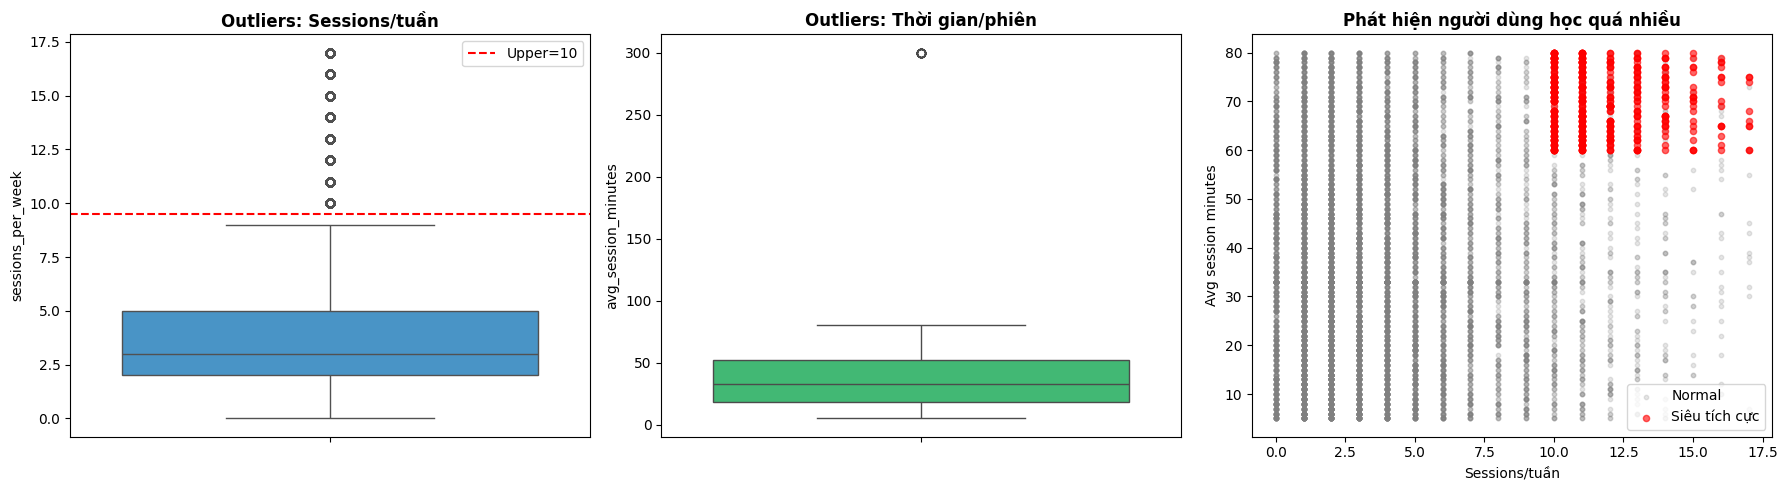

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot sessions
sns.boxplot(y=df["sessions_per_week"], ax=axes[0], color="#3498db")
axes[0].set_title("Outliers: Sessions/tuần", fontweight="bold")
axes[0].axhline(up_s, color="red", linestyle="--", label=f"Upper={up_s:.0f}")
axes[0].legend()

# Boxplot avg_session_minutes
sns.boxplot(y=df["avg_session_minutes"], ax=axes[1], color="#2ecc71")
axes[1].set_title("Outliers: Thời gian/phiên", fontweight="bold")

# Scatter: sessions vs minutes (highlight outliers)
sample_df = df.sample(10000, random_state=42)
axes[2].scatter(
    sample_df["sessions_per_week"],
    sample_df["avg_session_minutes"],
    alpha=0.2,
    s=10,
    color="gray",
    label="Normal",
)
super_sample = super_active.sample(min(500, len(super_active)), random_state=42)
axes[2].scatter(
    super_sample["sessions_per_week"],
    super_sample["avg_session_minutes"],
    alpha=0.6,
    s=20,
    color="red",
    label="Siêu tích cực",
)
axes[2].set_xlabel("Sessions/tuần")
axes[2].set_ylabel("Avg session minutes")
axes[2].set_title("Phát hiện người dùng học quá nhiều", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.show()

# 4.1. Người dùng đăng ký nhiều khóa nhưng không học


In [68]:
ghost_users = df[(df["courses_enrolled"] >= 10) & (df["completion_rate"] <= 0.1)]
print(
    f"Người dùng đăng ký nhiều khóa nhưng không học (đăng ký ≥10 khóa, hoàn thành ≤10%): {len(ghost_users):,}"
)
print(f"Tỷ lệ: {len(ghost_users)/len(df)*100:.2f}%")
print()

Người dùng đăng ký nhiều khóa nhưng không học (đăng ký ≥10 khóa, hoàn thành ≤10%): 27,972
Tỷ lệ: 5.59%



In [69]:
print("Thống kê nhóm Ghost Users:")
print(
    ghost_users[
        [
            "sessions_per_week",
            "avg_session_minutes",
            "videos_watched",
            "courses_enrolled",
            "completion_rate",
            "total_spent_usd",
            "premium_purchased",
            "churn_risk",
        ]
    ]
    .describe()
    .round(2)
)

Thống kê nhóm Ghost Users:
       sessions_per_week  avg_session_minutes  videos_watched  \
count           27972.00             27972.00        27972.00   
mean                3.66                35.88           20.56   
std                 3.06                20.61           14.05   
min                 0.00                 5.00            0.00   
25%                 2.00                18.00            8.00   
50%                 3.00                33.00           19.00   
75%                 5.00                52.00           32.00   
max                17.00               300.00           50.00   

       courses_enrolled  completion_rate  total_spent_usd  premium_purchased  \
count          27972.00         27972.00         27972.00           27972.00   
mean              13.05             0.05            38.02               0.28   
std                2.24             0.03            30.99               0.45   
min               10.00             0.00             0.00          

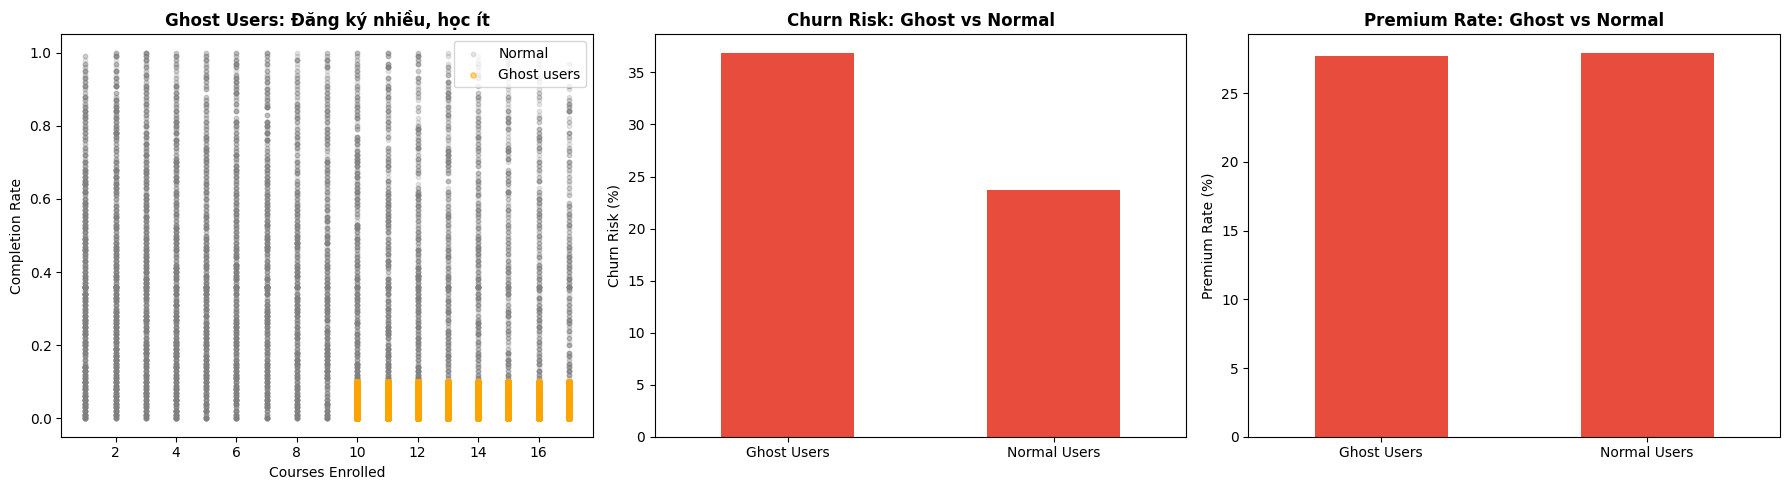

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# courses_enrolled vs completion_rate
sample_all = df.sample(10000, random_state=42)
axes[0].scatter(
    sample_all["courses_enrolled"],
    sample_all["completion_rate"],
    alpha=0.2,
    s=10,
    color="gray",
    label="Normal",
)
ghost_sample = ghost_users.sample(min(2000, len(ghost_users)), random_state=42)
axes[0].scatter(
    ghost_sample["courses_enrolled"],
    ghost_sample["completion_rate"],
    alpha=0.5,
    s=15,
    color="orange",
    label="Ghost users",
)
axes[0].set_xlabel("Courses Enrolled")
axes[0].set_ylabel("Completion Rate")
axes[0].set_title("Ghost Users: Đăng ký nhiều, học ít", fontweight="bold")
axes[0].legend()

# So sánh churn risk
groups = pd.DataFrame(
    {
        "Ghost Users": [ghost_users["churn_risk"].mean() * 100],
        "Normal Users": [
            df[~df.index.isin(ghost_users.index)]["churn_risk"].mean() * 100
        ],
    }
).T
groups.columns = ["Churn Risk (%)"]
groups.plot(kind="bar", ax=axes[1], color=["#e74c3c", "#2ecc71"], legend=False)
axes[1].set_title("Churn Risk: Ghost vs Normal", fontweight="bold")
axes[1].set_ylabel("Churn Risk (%)")
axes[1].tick_params(axis="x", rotation=0)

# Premium rate
premium = pd.DataFrame(
    {
        "Ghost Users": [ghost_users["premium_purchased"].mean() * 100],
        "Normal Users": [
            df[~df.index.isin(ghost_users.index)]["premium_purchased"].mean() * 100
        ],
    }
).T
premium.columns = ["Premium Rate (%)"]
premium.plot(kind="bar", ax=axes[2], color=["#e74c3c", "#3498db"], legend=False)
axes[2].set_title("Premium Rate: Ghost vs Normal", fontweight="bold")
axes[2].set_ylabel("Premium Rate (%)")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

# Nhận xét

# Nhóm Ghost Users đăng ký nhiều khóa (≥10) nhưng completion rate rất thấp (≤10%)

# Nhóm này có nguy cơ churn cao hơn đáng kể so với nhóm bình thường


# 4.2 . Người dùng chi tiêu bất thường


In [71]:
out_spent, low_sp, up_sp = detect_outliers_iqr(df, "total_spent_usd")
print(f"Total Spent USD - Ngưỡng IQR: [{low_sp:.1f}, {up_sp:.1f}]")
print(f"Số outliers chi tiêu: {len(out_spent):,} ({len(out_spent)/len(df)*100:.2f}%)")

# Người chi tiêu cao nhất
high_spenders = df[df["total_spent_usd"] >= 150].sort_values(
    "total_spent_usd", ascending=False
)
print(f"Người dùng chi tiêu ≥150 USD: {len(high_spenders):,}")
print(
    high_spenders[
        [
            "user_id",
            "total_spent_usd",
            "courses_enrolled",
            "completion_rate",
            "premium_purchased",
            "sessions_per_week",
        ]
    ].head(15)
)

# Người chi 0 USD nhưng premium
zero_spend_premium = df[(df["total_spent_usd"] == 0) & (df["premium_purchased"] == 1)]
print(f"Premium nhưng chi tiêu = 0 USD: {len(zero_spend_premium):,}")

Total Spent USD - Ngưỡng IQR: [-37.5, 102.5]
Số outliers chi tiêu: 22,410 (4.48%)
Người dùng chi tiêu ≥150 USD: 6,083
        user_id  total_spent_usd  courses_enrolled  completion_rate  \
420635   420636            350.0                 4             0.45   
402785   402786            350.0                 2             0.30   
27772     27773            350.0                 2             0.12   
152752   152753            350.0                 8             0.26   
367720   367721            350.0                 1             0.04   
483888   483889            350.0                 9             0.58   
240520   240521            350.0                 9             0.90   
468932   468933            350.0                14             0.52   
113396   113397            350.0                14             0.28   
297862   297863            350.0                11             0.11   
312280   312281            350.0                11             0.70   
20741     20742            350

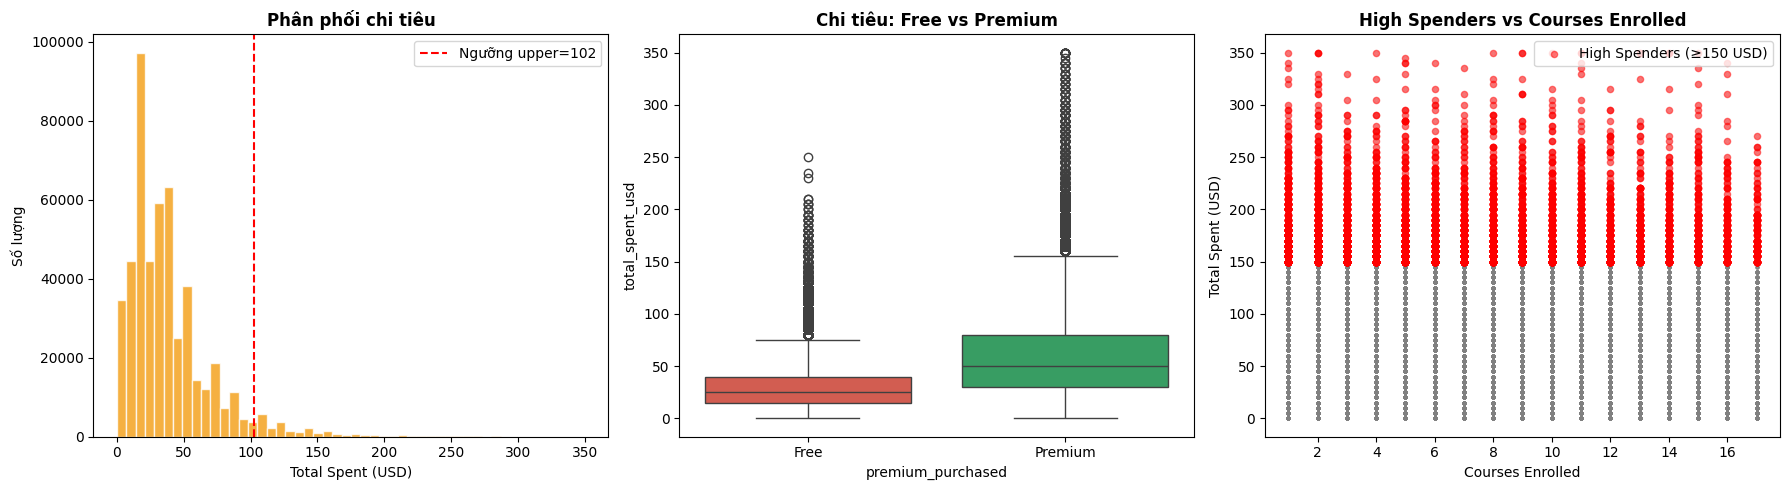

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram chi tiêu
axes[0].hist(
    df["total_spent_usd"], bins=50, color="#f39c12", edgecolor="white", alpha=0.8
)
axes[0].axvline(up_sp, color="red", linestyle="--", label=f"Ngưỡng upper={up_sp:.0f}")
axes[0].set_xlabel("Total Spent (USD)")
axes[0].set_ylabel("Số lượng")
axes[0].set_title("Phân phối chi tiêu", fontweight="bold")
axes[0].legend()

# Boxplot chi tiêu theo premium
sns.boxplot(
    x="premium_purchased",
    y="total_spent_usd",
    data=df,
    ax=axes[1],
    palette=["#e74c3c", "#27ae60"],
)
axes[1].set_xticklabels(["Free", "Premium"])
axes[1].set_title("Chi tiêu: Free vs Premium", fontweight="bold")

# Top spenders - scatter
axes[2].scatter(
    df["courses_enrolled"], df["total_spent_usd"], alpha=0.1, s=5, color="gray"
)
axes[2].scatter(
    high_spenders["courses_enrolled"],
    high_spenders["total_spent_usd"],
    alpha=0.5,
    s=20,
    color="red",
    label="High Spenders (≥150 USD)",
)
axes[2].set_xlabel("Courses Enrolled")
axes[2].set_ylabel("Total Spent (USD)")
axes[2].set_title("High Spenders vs Courses Enrolled", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.show()

# AS 2


# 5. PHÂN TÍCH MỐI QUAN HỆ GIỮA CÁC BIẾN


### 5.1 Thời gian học (avg_session_minutes) vs Completion Rate


In [73]:
from scipy.stats import pearsonr, spearmanr

# Phân tích tương quan
corr_pearson, p_pearson = pearsonr(df["avg_session_minutes"], df["completion_rate"])
corr_spearman, p_spearman = spearmanr(df["avg_session_minutes"], df["completion_rate"])

print("=" * 60)
print("5.1 THỜI GIAN HỌC vs COMPLETION RATE")
print("=" * 60)
print(f"Pearson Correlation: {corr_pearson:.4f} (p-value: {p_pearson:.4e})")
print(f"Spearman Correlation: {corr_spearman:.4f} (p-value: {p_spearman:.4e})")
print()

# Phân nhóm theo thời gian học
df["time_group"] = pd.cut(
    df["avg_session_minutes"],
    bins=[0, 15, 30, 45, 60, float("inf")],
    labels=["<15 phút", "15-30 phút", "30-45 phút", "45-60 phút", ">60 phút"],
)

print("Completion Rate trung bình theo nhóm thời gian:")
print(
    df.groupby("time_group", observed=True)[
        ["completion_rate", "courses_enrolled", "premium_purchased"]
    ]
    .agg(
        {
            "completion_rate": ["mean", "std", "count"],
            "courses_enrolled": "mean",
            "premium_purchased": lambda x: (x.sum() / len(x) * 100),
        }
    )
    .round(3)
)
print()

5.1 THỜI GIAN HỌC vs COMPLETION RATE
Pearson Correlation: 0.0016 (p-value: 2.4903e-01)
Spearman Correlation: 0.0016 (p-value: 2.6614e-01)

Completion Rate trung bình theo nhóm thời gian:
           completion_rate                courses_enrolled premium_purchased
                      mean    std   count             mean          <lambda>
time_group                                                                  
<15 phút             0.397  0.270  100614            7.504            27.970
15-30 phút           0.396  0.270  120507            7.515            27.773
30-45 phút           0.398  0.271  115883            7.517            27.808
45-60 phút           0.396  0.270   82583            7.490            28.046
>60 phút             0.399  0.270   80413            7.523            27.856



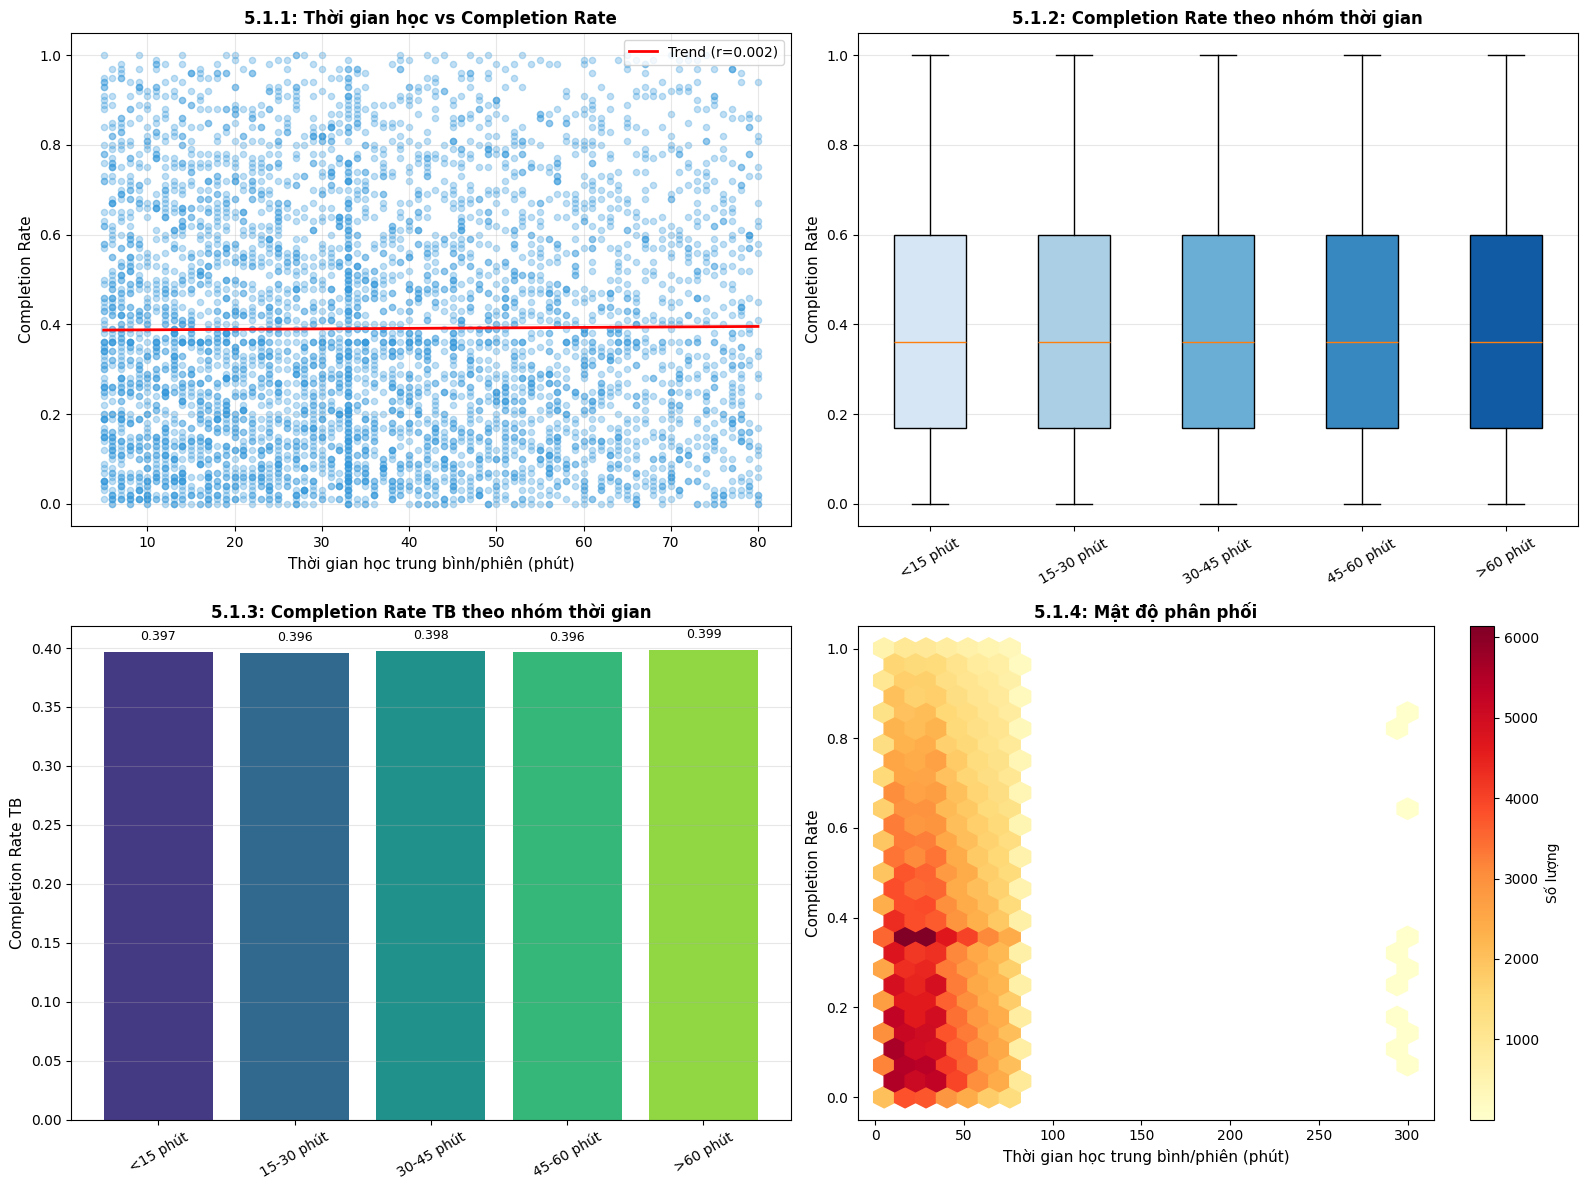

✓ Biểu đồ 5.1 hoàn thành


In [74]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter plot với hồi quy tuyến tính
sample_5k = df.sample(5000, random_state=42)
axes[0, 0].scatter(
    sample_5k["avg_session_minutes"],
    sample_5k["completion_rate"],
    alpha=0.3,
    s=20,
    color="#3498db",
)
z = np.polyfit(sample_5k["avg_session_minutes"], sample_5k["completion_rate"], 1)
p = np.poly1d(z)
x_line = np.linspace(
    sample_5k["avg_session_minutes"].min(), sample_5k["avg_session_minutes"].max(), 100
)
axes[0, 0].plot(
    x_line, p(x_line), "r-", linewidth=2, label=f"Trend (r={corr_pearson:.3f})"
)
axes[0, 0].set_xlabel("Thời gian học trung bình/phiên (phút)", fontsize=11)
axes[0, 0].set_ylabel("Completion Rate", fontsize=11)
axes[0, 0].set_title("5.1.1: Thời gian học vs Completion Rate", fontweight="bold")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Boxplot theo nhóm thời gian
group_order = ["<15 phút", "15-30 phút", "30-45 phút", "45-60 phút", ">60 phút"]
time_data = [df[df["time_group"] == g]["completion_rate"].values for g in group_order]
bp = axes[0, 1].boxplot(time_data, labels=group_order, patch_artist=True)
for patch, color in zip(bp["boxes"], sns.color_palette("Blues", 5)):
    patch.set_facecolor(color)
axes[0, 1].set_ylabel("Completion Rate", fontsize=11)
axes[0, 1].set_title("5.1.2: Completion Rate theo nhóm thời gian", fontweight="bold")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].grid(True, alpha=0.3, axis="y")

# 3. Completion rate trung bình theo nhóm
completion_by_time = df.groupby("time_group", observed=True)["completion_rate"].mean()
colors_grad = sns.color_palette("viridis", len(completion_by_time))
axes[1, 0].bar(
    range(len(completion_by_time)), completion_by_time.values, color=colors_grad
)
axes[1, 0].set_xticks(range(len(completion_by_time)))
axes[1, 0].set_xticklabels(completion_by_time.index, rotation=30)
axes[1, 0].set_ylabel("Completion Rate TB", fontsize=11)
axes[1, 0].set_title("5.1.3: Completion Rate TB theo nhóm thời gian", fontweight="bold")
for i, v in enumerate(completion_by_time.values):
    axes[1, 0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
axes[1, 0].grid(True, alpha=0.3, axis="y")

# 4. 2D Hexbin plot (mật độ điểm)
hexbin = axes[1, 1].hexbin(
    df["avg_session_minutes"],
    df["completion_rate"],
    gridsize=25,
    cmap="YlOrRd",
    mincnt=1,
)
axes[1, 1].set_xlabel("Thời gian học trung bình/phiên (phút)", fontsize=11)
axes[1, 1].set_ylabel("Completion Rate", fontsize=11)
axes[1, 1].set_title("5.1.4: Mật độ phân phối", fontweight="bold")
plt.colorbar(hexbin, ax=axes[1, 1], label="Số lượng")

plt.tight_layout()
plt.show()

print("✓ Biểu đồ 5.1 hoàn thành")

### 5.2 Số video xem (videos_watched) vs Khả năng mua khóa học (total_spent_usd & premium_purchased)


In [75]:
from scipy.stats import chi2_contingency

# Phân tích tương quan
corr_videos_spent = df["videos_watched"].corr(df["total_spent_usd"], method="spearman")
corr_videos_courses = df["videos_watched"].corr(
    df["courses_enrolled"], method="spearman"
)

print("=" * 60)
print("5.2 SỐ VIDEO XEM vs KHẢ NĂNG MUA KHÓA HỌC")
print("=" * 60)
print(f"Correlation: Videos Watched vs Total Spent: {corr_videos_spent:.4f}")
print(f"Correlation: Videos Watched vs Courses Enrolled: {corr_videos_courses:.4f}")
print()

# Phân nhóm theo số video xem
df["video_group"] = pd.cut(
    df["videos_watched"],
    bins=[0, 20, 50, 100, 200, float("inf")],
    labels=["1-20", "21-50", "51-100", "101-200", ">200"],
)

print("Chi tiêu trung bình theo nhóm số video xem:")
video_spending = (
    df.groupby("video_group", observed=True)[
        ["total_spent_usd", "premium_purchased", "courses_enrolled"]
    ]
    .agg(
        {
            "total_spent_usd": ["mean", "median", "std"],
            "premium_purchased": lambda x: (x.sum() / len(x) * 100),
            "courses_enrolled": "mean",
        }
    )
    .round(2)
)
print(video_spending)
print()

5.2 SỐ VIDEO XEM vs KHẢ NĂNG MUA KHÓA HỌC
Correlation: Videos Watched vs Total Spent: 0.0027
Correlation: Videos Watched vs Courses Enrolled: -0.0003

Chi tiêu trung bình theo nhóm số video xem:
            total_spent_usd               premium_purchased courses_enrolled
                       mean median    std          <lambda>             mean
video_group                                                                 
1-20                  38.01   30.0  31.22             27.83             7.51
21-50                 38.17   30.0  31.28             27.93             7.51



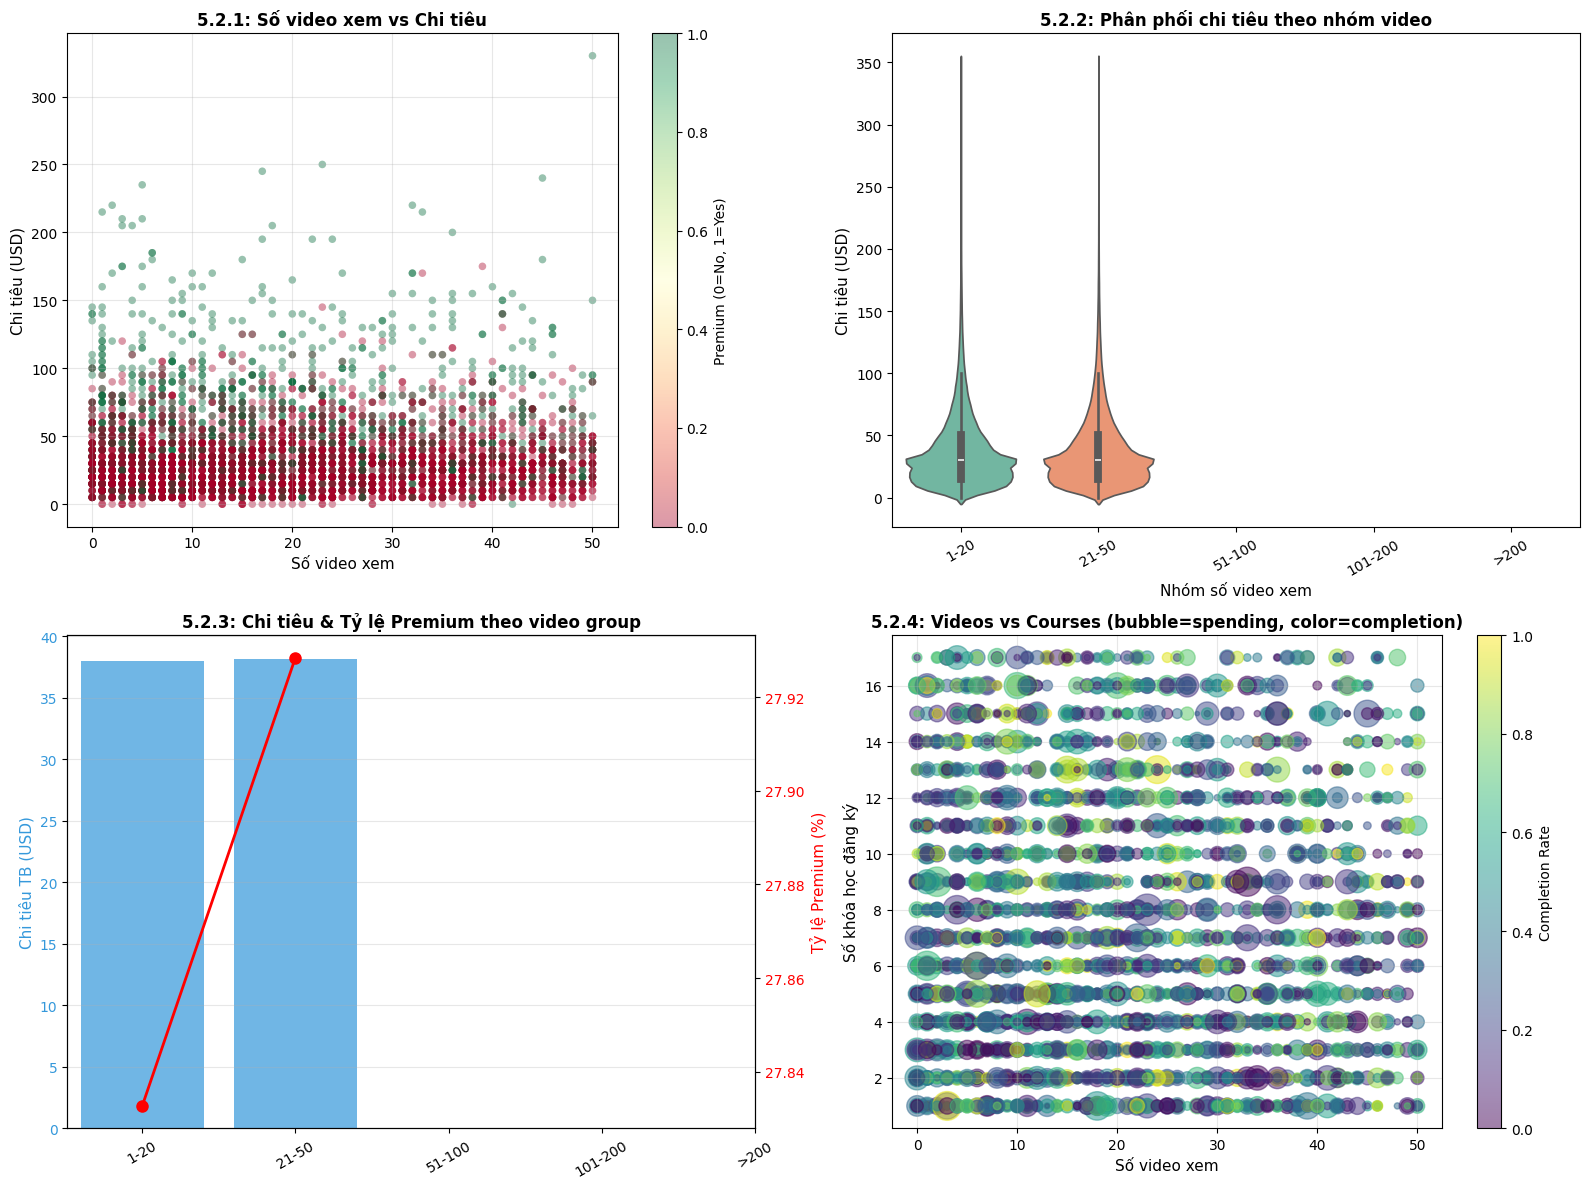

✓ Biểu đồ 5.2 hoàn thành


In [76]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter plot: Videos watched vs Total spent
sample_5k = df.sample(5000, random_state=42)
scatter = axes[0, 0].scatter(
    sample_5k["videos_watched"],
    sample_5k["total_spent_usd"],
    c=sample_5k["premium_purchased"],
    cmap="RdYlGn",
    alpha=0.4,
    s=30,
    edgecolors="none",
)
axes[0, 0].set_xlabel("Số video xem", fontsize=11)
axes[0, 0].set_ylabel("Chi tiêu (USD)", fontsize=11)
axes[0, 0].set_title("5.2.1: Số video xem vs Chi tiêu", fontweight="bold")
plt.colorbar(scatter, ax=axes[0, 0], label="Premium (0=No, 1=Yes)")
axes[0, 0].grid(True, alpha=0.3)

# 2. Violin plot theo video group
video_order = ["1-20", "21-50", "51-100", "101-200", ">200"]
sns.violinplot(
    data=df[df["video_group"].isin(video_order)],
    x="video_group",
    y="total_spent_usd",
    order=video_order,
    ax=axes[0, 1],
    palette="Set2",
)
axes[0, 1].set_xlabel("Nhóm số video xem", fontsize=11)
axes[0, 1].set_ylabel("Chi tiêu (USD)", fontsize=11)
axes[0, 1].set_title("5.2.2: Phân phối chi tiêu theo nhóm video", fontweight="bold")
axes[0, 1].tick_params(axis="x", rotation=30)

# 3. Bar plot: Chi tiêu TB theo video group
spending_by_video = (
    df.groupby("video_group", observed=True)["total_spent_usd"]
    .mean()
    .reindex(video_order)
)
premium_rate = (
    df.groupby("video_group", observed=True)["premium_purchased"]
    .mean()
    .reindex(video_order)
    * 100
)

ax3_1 = axes[1, 0]
ax3_2 = ax3_1.twinx()
bars = ax3_1.bar(
    range(len(spending_by_video)),
    spending_by_video.values,
    color="#3498db",
    alpha=0.7,
    label="Chi tiêu TB",
)
line = ax3_2.plot(
    range(len(premium_rate)),
    premium_rate.values,
    "ro-",
    linewidth=2,
    markersize=8,
    label="Tỷ lệ Premium %",
)
ax3_1.set_xticks(range(len(spending_by_video)))
ax3_1.set_xticklabels(spending_by_video.index, rotation=30)
ax3_1.set_ylabel("Chi tiêu TB (USD)", fontsize=11, color="#3498db")
ax3_2.set_ylabel("Tỷ lệ Premium (%)", fontsize=11, color="red")
ax3_1.set_title("5.2.3: Chi tiêu & Tỷ lệ Premium theo video group", fontweight="bold")
ax3_1.tick_params(axis="y", labelcolor="#3498db")
ax3_2.tick_params(axis="y", labelcolor="red")
ax3_1.grid(True, alpha=0.3, axis="y")

# 4. Bubble plot: Videos watched vs Courses Enrolled (bubble size = spending)
sample_bubble = df.sample(3000, random_state=42)
scatter2 = axes[1, 1].scatter(
    sample_bubble["videos_watched"],
    sample_bubble["courses_enrolled"],
    s=sample_bubble["total_spent_usd"] * 2 + 10,
    c=sample_bubble["completion_rate"],
    alpha=0.5,
    cmap="viridis",
)
axes[1, 1].set_xlabel("Số video xem", fontsize=11)
axes[1, 1].set_ylabel("Số khóa học đăng ký", fontsize=11)
axes[1, 1].set_title(
    "5.2.4: Videos vs Courses (bubble=spending, color=completion)", fontweight="bold"
)
plt.colorbar(scatter2, ax=axes[1, 1], label="Completion Rate")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Biểu đồ 5.2 hoàn thành")

# 6. PHÂN CỤM NGƯỜI DÙNG (USER CLUSTERING)


### 6.1 Chuẩn bị dữ liệu và thực hiện phân cụm K-Means


In [77]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Chọn các thuộc tính để clustering
clustering_features = [
    "avg_session_minutes",  # Thời gian học
    "sessions_per_week",  # Số phiên/tuần
    "videos_watched",  # Số video xem
    "courses_enrolled",  # Số khóa học
    "completion_rate",  # Tỷ lệ hoàn thành
    "forum_posts",  # Bài đăng forum
    "total_spent_usd",  # Chi tiêu
    "ai_recommend_click",  # AI recommendation clicks
]

# Chuẩn bị dữ liệu
X_cluster = df[clustering_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Số lượng user: {len(df):,}")
print(f"Số lượng thuộc tính: {len(clustering_features)}")
print(f"Thuộc tính: {', '.join(clustering_features)}")
print()

# Dùng sample nhỏ để chọn K nhanh hơn khi dữ liệu lớn
sample_size = min(len(X_scaled), 2000)
if len(X_scaled) > sample_size:
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(X_scaled), size=sample_size, replace=False)
    X_search = X_scaled[sample_idx]
    print(f"Đang dùng sample {sample_size:,} user để đánh giá K...")
else:
    X_search = X_scaled
    print("Đang dùng toàn bộ dữ liệu để đánh giá K...")
print()

# Giới hạn dải K để giảm thời gian chạy
inertias = []
silhouette_scores = []
K_range = range(2, 7)

for k in K_range:
    kmeans_temp = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=512,
        n_init="auto",
        max_iter=300,
    )
    kmeans_temp.fit(X_search)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_search, kmeans_temp.labels_))

print("K-Means Evaluation:")
for k, inertia, sil_score in zip(K_range, inertias, silhouette_scores):
    print(f"  K={k}: Inertia={inertia:.2f}, Silhouette={sil_score:.4f}")
print()

# Chọn K=4 theo yêu cầu
optimal_k = 4
print(f"Chọn K = {optimal_k} (theo yêu cầu)")
print()

Số lượng user: 500,000
Số lượng thuộc tính: 8
Thuộc tính: avg_session_minutes, sessions_per_week, videos_watched, courses_enrolled, completion_rate, forum_posts, total_spent_usd, ai_recommend_click

Đang dùng sample 2,000 user để đánh giá K...

K-Means Evaluation:
  K=2: Inertia=14530.72, Silhouette=0.1003
  K=3: Inertia=13308.72, Silhouette=0.0970
  K=4: Inertia=12470.59, Silhouette=0.0932
  K=5: Inertia=11885.37, Silhouette=0.0886
  K=6: Inertia=11384.86, Silhouette=0.0881

Chọn K = 4 (theo yêu cầu)



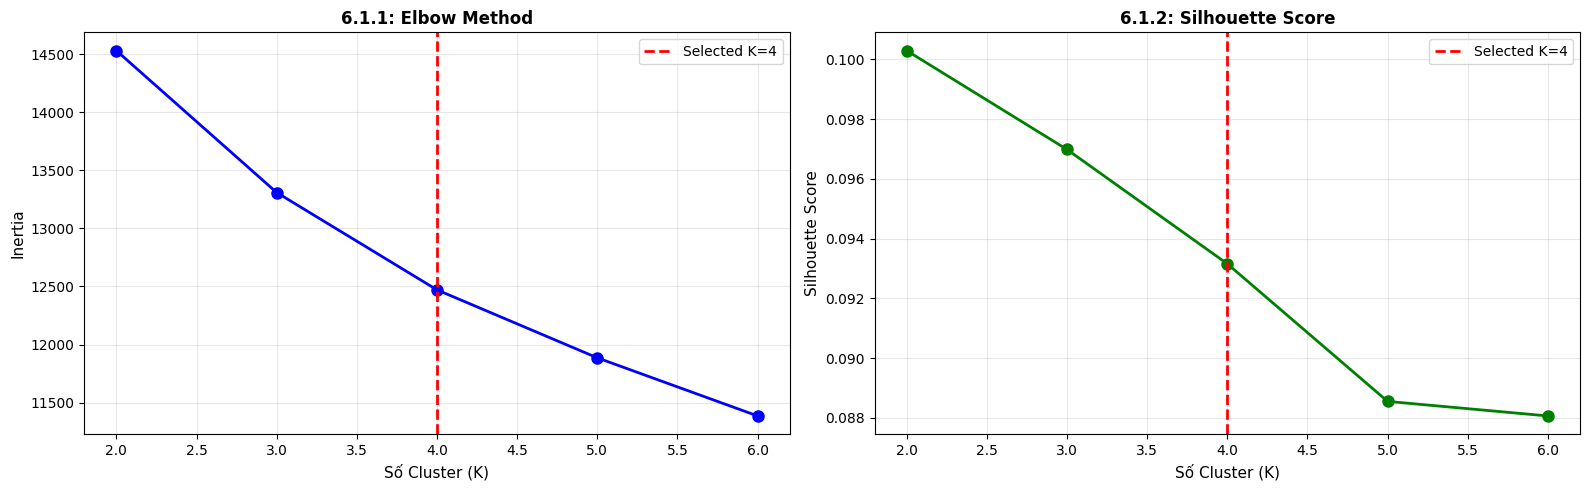

✓ Biểu đồ Elbow & Silhouette hoàn thành



In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow plot
axes[0].plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
axes[0].axvline(
    x=optimal_k, color="r", linestyle="--", linewidth=2, label=f"Selected K={optimal_k}"
)
axes[0].set_xlabel("Số Cluster (K)", fontsize=11)
axes[0].set_ylabel("Inertia", fontsize=11)
axes[0].set_title("6.1.1: Elbow Method", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette score plot
axes[1].plot(K_range, silhouette_scores, "go-", linewidth=2, markersize=8)
axes[1].axvline(
    x=optimal_k, color="r", linestyle="--", linewidth=2, label=f"Selected K={optimal_k}"
)
axes[1].set_xlabel("Số Cluster (K)", fontsize=11)
axes[1].set_ylabel("Silhouette Score", fontsize=11)
axes[1].set_title("6.1.2: Silhouette Score", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Biểu đồ Elbow & Silhouette hoàn thành")
print()

In [79]:
# Huấn luyện K-Means với K=4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Đặt tên cho các cluster
cluster_names = {0: "Cluster 0", 1: "Cluster 1", 2: "Cluster 2", 3: "Cluster 3"}

# Phân tích từng cluster
print("=" * 60)
print("KẾT QUẢ PHÂN CỤM K-MEANS (K=4)")
print("=" * 60)

for cluster_id in range(optimal_k):
    cluster_data = df[df["cluster"] == cluster_id]
    print(
        f"\n{cluster_names[cluster_id]} - Số lượng user: {len(cluster_data):,} ({len(cluster_data)/len(df)*100:.1f}%)"
    )
    print("-" * 50)

    print("Thống kê chính:")
    for feature in clustering_features:
        mean_val = cluster_data[feature].mean()
        std_val = cluster_data[feature].std()
        print(f"  {feature:25s}: {mean_val:8.2f} ± {std_val:6.2f}")

    print(f"  Premium Rate: {cluster_data['premium_purchased'].mean()*100:.1f}%")
    print(f"  Churn Risk: {cluster_data['churn_risk'].mean()*100:.1f}%")

# Gán tên cho cluster dựa trên đặc điểm
cluster_characteristics = {}
for cluster_id in range(optimal_k):
    cluster_data = df[df["cluster"] == cluster_id]

    avg_time = cluster_data["avg_session_minutes"].mean()
    avg_courses = cluster_data["courses_enrolled"].mean()
    avg_quiz = cluster_data["forum_posts"].mean()
    activity = cluster_data["sessions_per_week"].mean()

    if (
        avg_time > df["avg_session_minutes"].mean()
        and avg_courses > df["courses_enrolled"].mean()
    ):
        name = "Power Learner"
        desc = "Học nhiều, thời gian dài, hoạt động cao"
    elif (
        avg_time < df["avg_session_minutes"].mean()
        and avg_courses < df["courses_enrolled"].mean()
    ):
        name = "Casual Learner"
        desc = "Học ít, thời gian ngắn"
    elif avg_quiz > df["forum_posts"].quantile(0.75):
        name = "Certificate Hunter"
        desc = "Làm nhiều quiz/forum, tập trung hoàn thành"
    else:
        name = "Passive User"
        desc = "Ít hoạt động, tham gia tối thiểu"

    cluster_characteristics[cluster_id] = (name, desc)
    df.loc[df["cluster"] == cluster_id, "cluster_name"] = name

print("\n" + "=" * 60)
print("PHÂN LOẠI CLUSTER")
print("=" * 60)
for cluster_id, (name, desc) in cluster_characteristics.items():
    print(f"Cluster {cluster_id}: {name} - {desc}")

KẾT QUẢ PHÂN CỤM K-MEANS (K=4)

Cluster 0 - Số lượng user: 169,843 (34.0%)
--------------------------------------------------
Thống kê chính:
  avg_session_minutes      :    36.04 ±  20.80
  sessions_per_week        :     2.61 ±   1.70
  videos_watched           :    20.73 ±  14.09
  courses_enrolled         :     4.26 ±   2.40
  completion_rate          :     0.40 ±   0.27
  forum_posts              :     5.38 ±   3.97
  total_spent_usd          :    37.82 ±  30.88
  ai_recommend_click       :     4.14 ±   2.89
  Premium Rate: 27.7%
  Churn Risk: 25.2%

Cluster 1 - Số lượng user: 131,156 (26.2%)
--------------------------------------------------
Thống kê chính:
  avg_session_minutes      :    36.01 ±  20.71
  sessions_per_week        :     2.75 ±   1.83
  videos_watched           :    20.67 ±  14.07
  courses_enrolled         :    13.07 ±   2.45
  completion_rate          :     0.40 ±   0.27
  forum_posts              :     5.39 ±   3.97
  total_spent_usd          :    38.06 ±  31.14


### 6.2 Biểu diễn hành vi cluster bằng Star Glyphs


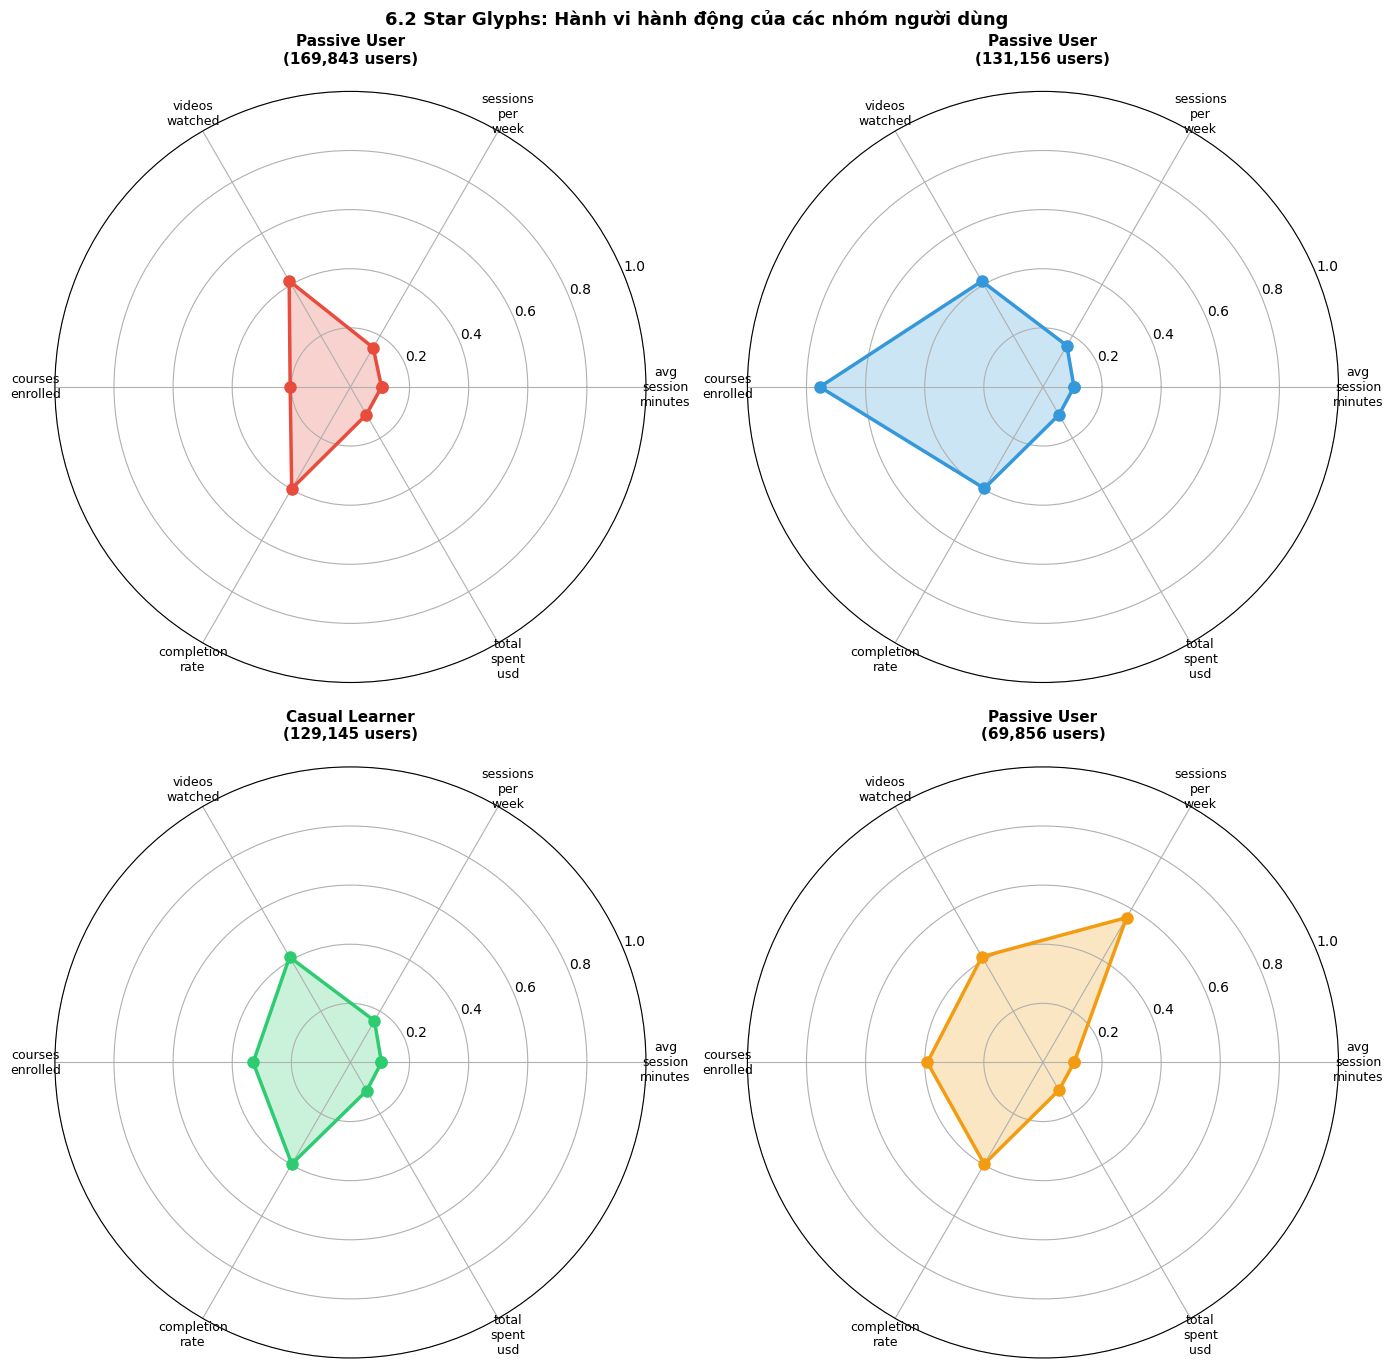

 Star Glyphs hoàn thành


In [80]:
def draw_star_glyph(ax, values, cluster_id, cluster_name, color):
    """
    Vẽ Star Glyph (biểu đồ sao) để hiển thị các thuộc tính
    values: list các giá trị đã chuẩn hóa [0, 1]
    """
    n_attributes = len(values)
    angles = np.linspace(0, 2 * np.pi, n_attributes, endpoint=False).tolist()
    values_plot = values + [values[0]]  # Đóng vòng tròn
    angles_plot = angles + [angles[0]]

    ax.plot(
        angles_plot, values_plot, "o-", linewidth=2, color=color, label=cluster_name
    )
    ax.fill(angles_plot, values_plot, alpha=0.25, color=color)

    return ax


# Chuẩn bị dữ liệu cho Star Glyphs
star_features = [
    "avg_session_minutes",
    "sessions_per_week",
    "videos_watched",
    "courses_enrolled",
    "completion_rate",
    "total_spent_usd",
]

# Chuẩn hóa dữ liệu cho từng feature [0, 1]
cluster_profiles = []
for cluster_id in range(optimal_k):
    cluster_data = df[df["cluster"] == cluster_id]
    profile = []
    for feature in star_features:
        min_val = df[feature].min()
        max_val = df[feature].max()
        mean_val = cluster_data[feature].mean()
        normalized = (
            (mean_val - min_val) / (max_val - min_val) if max_val > min_val else 0
        )
        profile.append(normalized)
    cluster_profiles.append(profile)

# Vẽ Star Glyphs
fig, axes = plt.subplots(2, 2, figsize=(14, 14), subplot_kw=dict(projection="polar"))
axes = axes.flatten()
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

n_attributes = len(star_features)
angles = np.linspace(0, 2 * np.pi, n_attributes, endpoint=False).tolist()

for cluster_id in range(optimal_k):
    ax = axes[cluster_id]
    profile = cluster_profiles[cluster_id]
    profile_plot = profile + [profile[0]]
    angles_plot = angles + [angles[0]]

    ax.plot(
        angles_plot,
        profile_plot,
        "o-",
        linewidth=2.5,
        color=colors[cluster_id],
        markersize=8,
    )
    ax.fill(angles_plot, profile_plot, alpha=0.25, color=colors[cluster_id])
    ax.set_xticks(angles)
    ax.set_xticklabels([f.replace("_", "\n") for f in star_features], fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(
        f'{cluster_characteristics[cluster_id][0]}\n({len(df[df["cluster"] == cluster_id]):,} users)',
        fontsize=11,
        fontweight="bold",
        pad=20,
    )
    ax.grid(True)

plt.suptitle(
    "6.2 Star Glyphs: Hành vi hành động của các nhóm người dùng",
    fontsize=13,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()

print(" Star Glyphs hoàn thành")

### 6.4 Biểu diễn cấu trúc cluster bằng Treemap


In [81]:
import plotly.graph_objects as go
import plotly.express as px

# Chuẩn bị dữ liệu cho Treemap
treemap_data = []
for cluster_id in range(optimal_k):
    cluster_data = df[df["cluster"] == cluster_id]
    cluster_size = len(cluster_data)
    cluster_name = cluster_characteristics[cluster_id][0]

    # Thêm tổng cluster
    treemap_data.append(
        {
            "labels": cluster_name,
            "parents": "All Users",
            "values": cluster_size,
            "text": f"{cluster_name}<br>{cluster_size:,} users ({cluster_size/len(df)*100:.1f}%)",
            "color": cluster_size,
        }
    )

# Thêm root node
treemap_data.insert(
    0,
    {
        "labels": "All Users",
        "parents": "",
        "values": len(df),
        "text": f"All Users<br>{len(df):,} users",
        "color": 0,
    },
)

df_treemap = pd.DataFrame(treemap_data)

fig = go.Figure(
    go.Treemap(
        labels=df_treemap["labels"],
        parents=df_treemap["parents"],
        values=df_treemap["values"],
        text=df_treemap["text"],
        textposition="middle center",
        marker=dict(
            colorscale="Viridis",
            cmid=np.median(df_treemap["color"]),
            colorbar=dict(title="User Count"),
            line=dict(width=2, color="white"),
        ),
        hovertext=df_treemap["text"],
        hoverinfo="text",
    )
)

fig.update_layout(
    title="6.4 Treemap: Cấu trúc các nhóm hành vi người dùng",
    width=1000,
    height=700,
    font=dict(size=12),
)

fig.show()
print("✓ Treemap hoàn thành")
print()

✓ Treemap hoàn thành



### 7. Phân phối hành vi người dùng


7.1 PHÂN PHỐI HÀNH VI NGƯỜI DÙNG


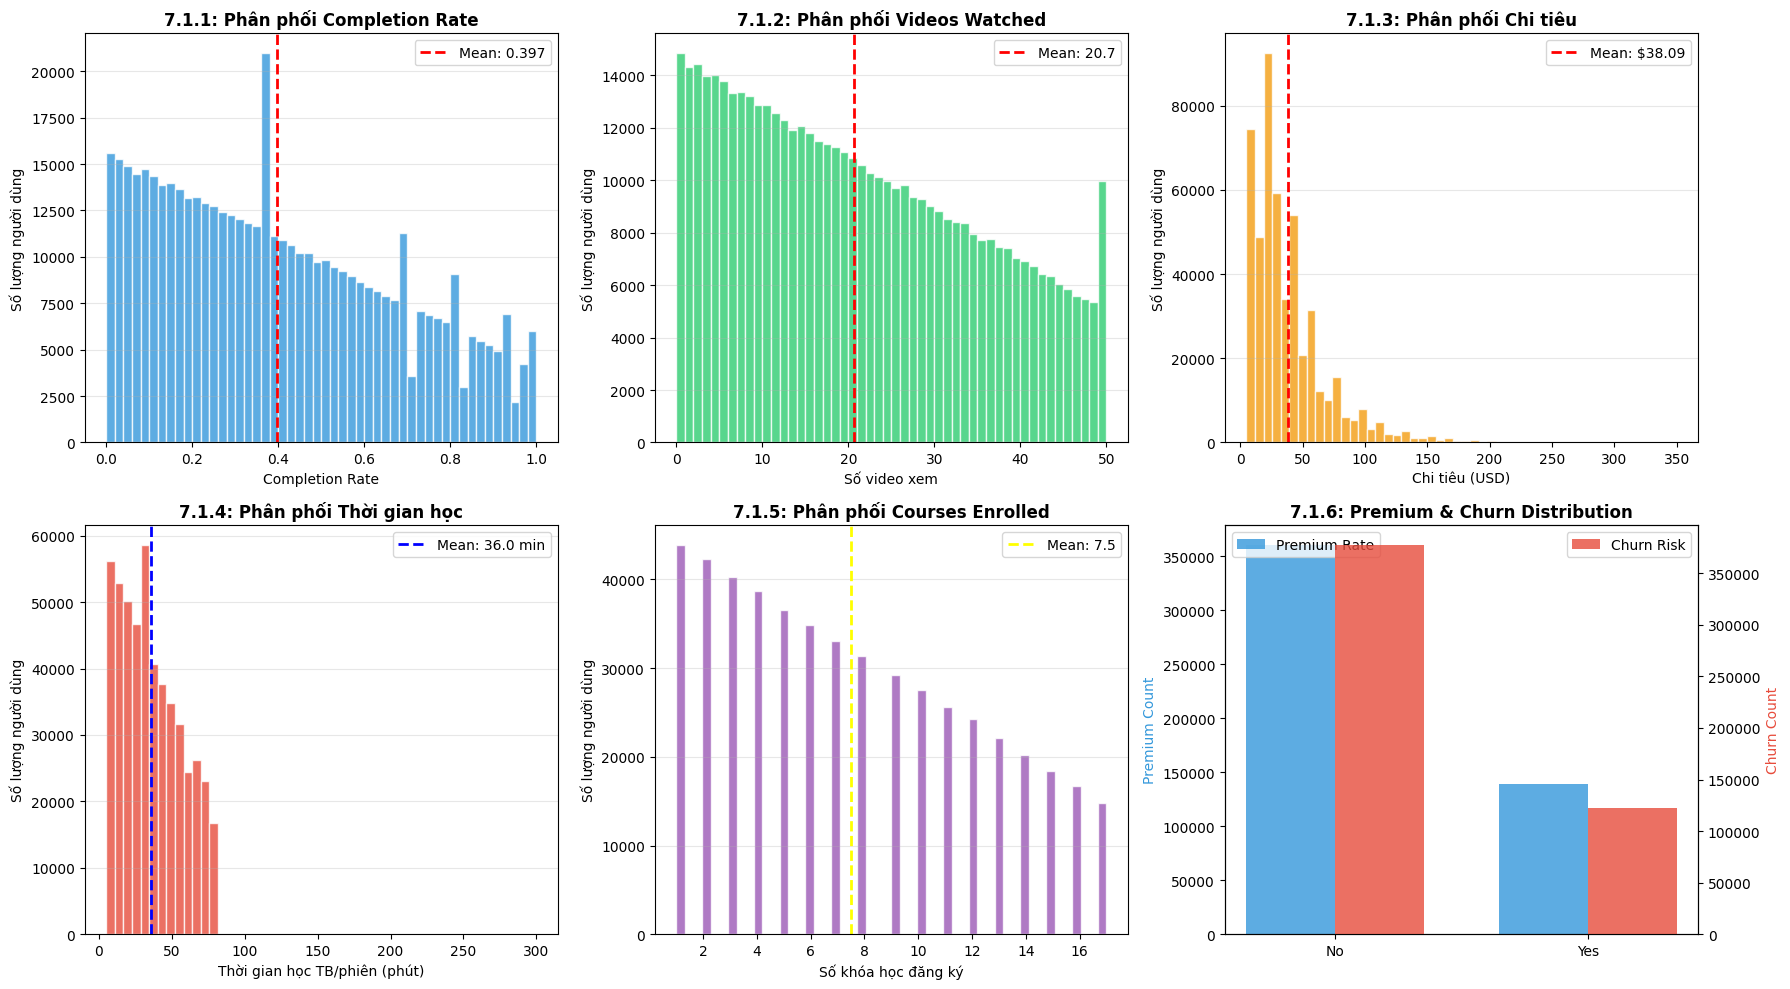

OK


In [82]:
print("=" * 60)
print("7.1 PHÂN PHỐI HÀNH VI NGƯỜI DÙNG")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Phân phối completion rate
axes[0, 0].hist(
    df["completion_rate"], bins=50, color="#3498db", edgecolor="white", alpha=0.8
)
axes[0, 0].axvline(
    df["completion_rate"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f'Mean: {df["completion_rate"].mean():.3f}',
)
axes[0, 0].set_xlabel("Completion Rate", fontsize=10)
axes[0, 0].set_ylabel("Số lượng người dùng", fontsize=10)
axes[0, 0].set_title("7.1.1: Phân phối Completion Rate", fontweight="bold")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis="y")

# 2. Phân phối số video xem
axes[0, 1].hist(
    df["videos_watched"], bins=50, color="#2ecc71", edgecolor="white", alpha=0.8
)
axes[0, 1].axvline(
    df["videos_watched"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f'Mean: {df["videos_watched"].mean():.1f}',
)
axes[0, 1].set_xlabel("Số video xem", fontsize=10)
axes[0, 1].set_ylabel("Số lượng người dùng", fontsize=10)
axes[0, 1].set_title("7.1.2: Phân phối Videos Watched", fontweight="bold")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis="y")

# 3. Phân phối chi tiêu
axes[0, 2].hist(
    df[df["total_spent_usd"] > 0]["total_spent_usd"],
    bins=50,
    color="#f39c12",
    edgecolor="white",
    alpha=0.8,
)
axes[0, 2].axvline(
    df["total_spent_usd"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f'Mean: ${df["total_spent_usd"].mean():.2f}',
)
axes[0, 2].set_xlabel("Chi tiêu (USD)", fontsize=10)
axes[0, 2].set_ylabel("Số lượng người dùng", fontsize=10)
axes[0, 2].set_title("7.1.3: Phân phối Chi tiêu", fontweight="bold")
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3, axis="y")

# 4. Phân phối thời gian học
axes[1, 0].hist(
    df["avg_session_minutes"], bins=50, color="#e74c3c", edgecolor="white", alpha=0.8
)
axes[1, 0].axvline(
    df["avg_session_minutes"].mean(),
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f'Mean: {df["avg_session_minutes"].mean():.1f} min',
)
axes[1, 0].set_xlabel("Thời gian học TB/phiên (phút)", fontsize=10)
axes[1, 0].set_ylabel("Số lượng người dùng", fontsize=10)
axes[1, 0].set_title("7.1.4: Phân phối Thời gian học", fontweight="bold")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis="y")

# 5. Phân phối số khóa học
axes[1, 1].hist(
    df["courses_enrolled"], bins=50, color="#9b59b6", edgecolor="white", alpha=0.8
)
axes[1, 1].axvline(
    df["courses_enrolled"].mean(),
    color="yellow",
    linestyle="--",
    linewidth=2,
    label=f'Mean: {df["courses_enrolled"].mean():.1f}',
)
axes[1, 1].set_xlabel("Số khóa học đăng ký", fontsize=10)
axes[1, 1].set_ylabel("Số lượng người dùng", fontsize=10)
axes[1, 1].set_title("7.1.5: Phân phối Courses Enrolled", fontweight="bold")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis="y")

# 6. Phân phối Premium vs Churn
premium_counts = df["premium_purchased"].value_counts()
churn_counts = df["churn_risk"].value_counts()

x = np.arange(2)
width = 0.35
bars1 = axes[1, 2].bar(
    x - width / 2,
    [premium_counts.get(0, 0), premium_counts.get(1, 0)],
    width,
    label="Premium Rate",
    color="#3498db",
    alpha=0.8,
)
ax_twin = axes[1, 2].twinx()
bars2 = ax_twin.bar(
    x + width / 2,
    [churn_counts.get(0, 0), churn_counts.get(1, 0)],
    width,
    label="Churn Risk",
    color="#e74c3c",
    alpha=0.8,
)
axes[1, 2].set_ylabel("Premium Count", fontsize=10, color="#3498db")
ax_twin.set_ylabel("Churn Count", fontsize=10, color="#e74c3c")
axes[1, 2].set_title("7.1.6: Premium & Churn Distribution", fontweight="bold")
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(["No", "Yes"])
axes[1, 2].legend(loc="upper left")
ax_twin.legend(loc="upper right")

plt.tight_layout()
plt.show()

print("OK")

### 7.3 Xu hướng học tập theo cluster


7.3 XU HƯỚNG HỌC TẬP THEO CLUSTER


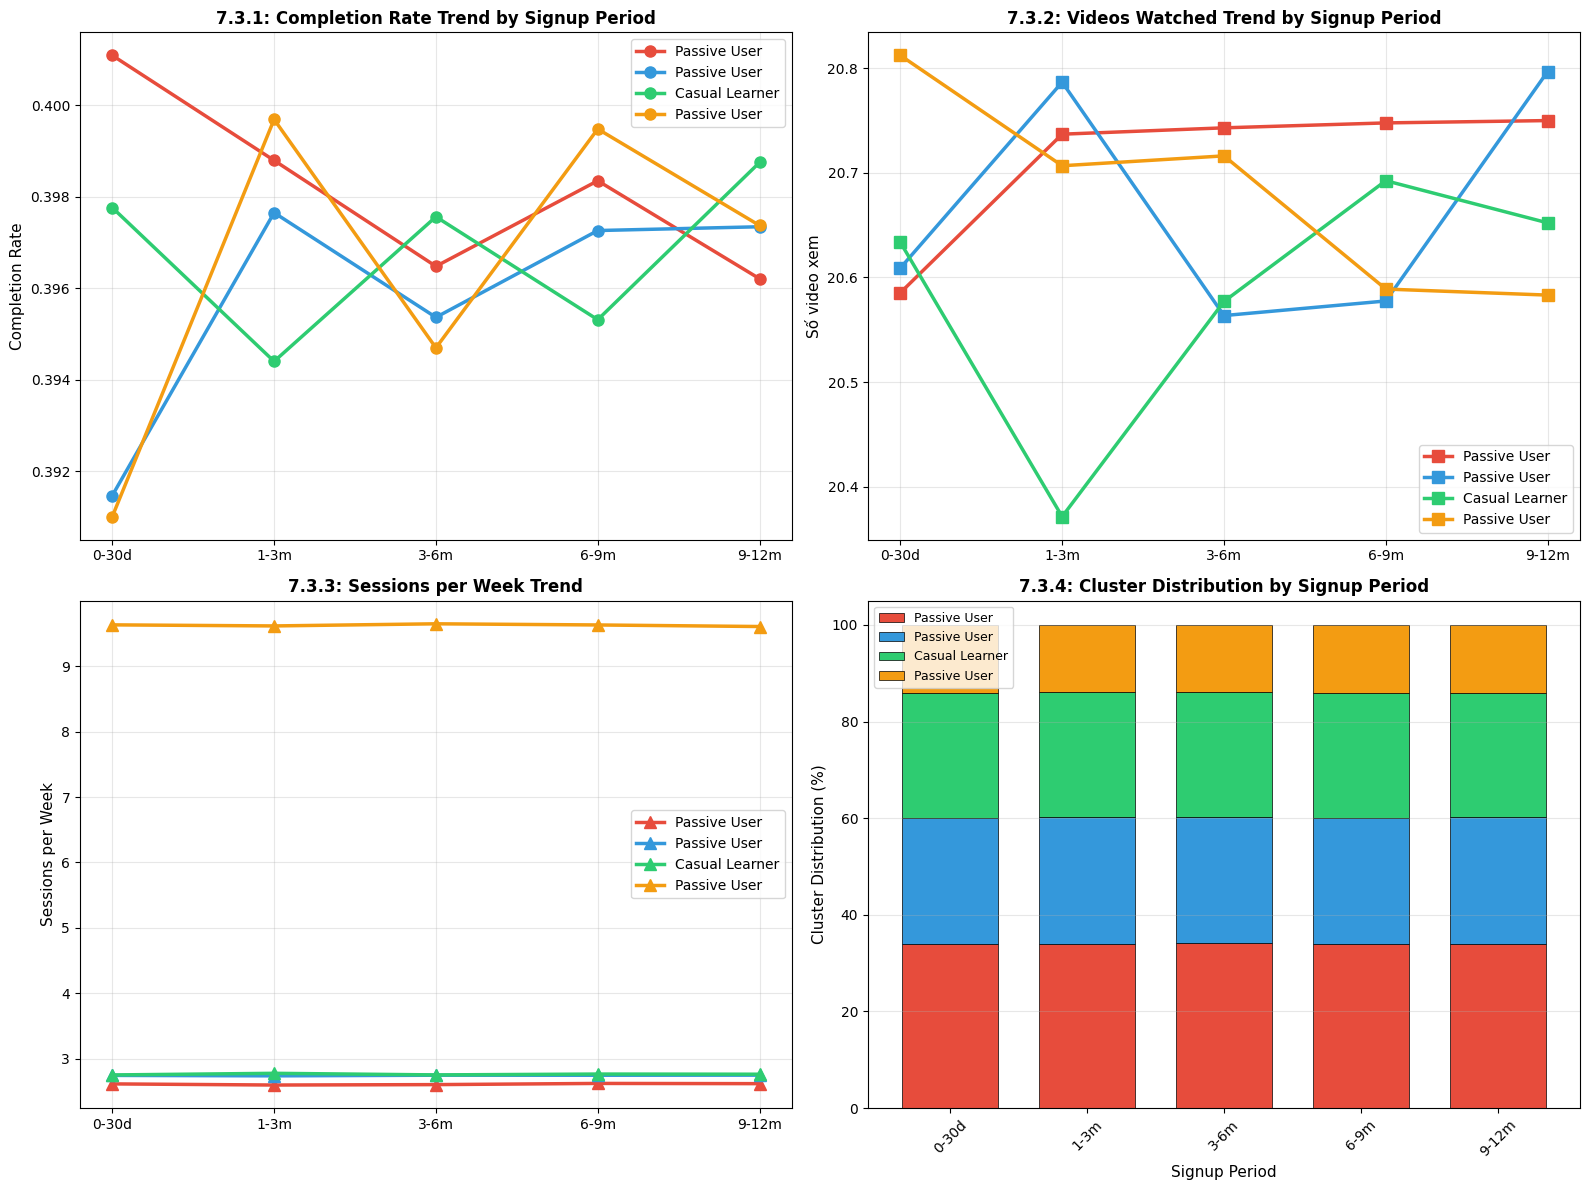

OK


In [83]:
print("=" * 60)
print("7.3 XU HƯỚNG HỌC TẬP THEO CLUSTER")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

df_temp = df.copy()
df_temp["signup_period"] = pd.cut(
    df_temp["signup_days_ago"],
    bins=[0, 30, 90, 180, 270, 365],
    labels=["0-30d", "1-3m", "3-6m", "6-9m", "9-12m"],
)

signup_order = ["0-30d", "1-3m", "3-6m", "6-9m", "9-12m"]
for cluster_id in range(optimal_k):
    cluster_trend = (
        df_temp[df_temp["cluster"] == cluster_id]
        .groupby("signup_period", observed=True)["completion_rate"]
        .mean()
    )
    cluster_trend = cluster_trend.reindex(signup_order)
    axes[0, 0].plot(
        range(len(cluster_trend)),
        cluster_trend.values,
        "o-",
        linewidth=2.5,
        markersize=8,
        label=cluster_characteristics[cluster_id][0],
        color=colors[cluster_id],
    )

axes[0, 0].set_xticks(range(len(signup_order)))
axes[0, 0].set_xticklabels(signup_order)
axes[0, 0].set_ylabel("Completion Rate", fontsize=11)
axes[0, 0].set_title("7.3.1: Completion Rate Trend by Signup Period", fontweight="bold")
axes[0, 0].legend(loc="best")
axes[0, 0].grid(True, alpha=0.3)

# 2. Video Watched Trend
for cluster_id in range(optimal_k):
    cluster_trend = (
        df_temp[df_temp["cluster"] == cluster_id]
        .groupby("signup_period", observed=True)["videos_watched"]
        .mean()
    )
    cluster_trend = cluster_trend.reindex(signup_order)
    axes[0, 1].plot(
        range(len(cluster_trend)),
        cluster_trend.values,
        "s-",
        linewidth=2.5,
        markersize=8,
        label=cluster_characteristics[cluster_id][0],
        color=colors[cluster_id],
    )

axes[0, 1].set_xticks(range(len(signup_order)))
axes[0, 1].set_xticklabels(signup_order)
axes[0, 1].set_ylabel("Số video xem", fontsize=11)
axes[0, 1].set_title("7.3.2: Videos Watched Trend by Signup Period", fontweight="bold")
axes[0, 1].legend(loc="best")
axes[0, 1].grid(True, alpha=0.3)

# 3. Sessions per Week Trend
for cluster_id in range(optimal_k):
    cluster_trend = (
        df_temp[df_temp["cluster"] == cluster_id]
        .groupby("signup_period", observed=True)["sessions_per_week"]
        .mean()
    )
    cluster_trend = cluster_trend.reindex(signup_order)
    axes[1, 0].plot(
        range(len(cluster_trend)),
        cluster_trend.values,
        "^-",
        linewidth=2.5,
        markersize=8,
        label=cluster_characteristics[cluster_id][0],
        color=colors[cluster_id],
    )

axes[1, 0].set_xticks(range(len(signup_order)))
axes[1, 0].set_xticklabels(signup_order)
axes[1, 0].set_ylabel("Sessions per Week", fontsize=11)
axes[1, 0].set_title("7.3.3: Sessions per Week Trend", fontweight="bold")
axes[1, 0].legend(loc="best")
axes[1, 0].grid(True, alpha=0.3)

# 4. Cluster Distribution over Signup Periods
cluster_dist = (
    pd.crosstab(df_temp["signup_period"], df_temp["cluster"], normalize="index") * 100
)
cluster_dist = cluster_dist.reindex(signup_order)
cluster_dist.plot(
    kind="bar",
    stacked=True,
    ax=axes[1, 1],
    color=colors,
    width=0.7,
    edgecolor="black",
    linewidth=0.5,
)
axes[1, 1].set_xlabel("Signup Period", fontsize=11)
axes[1, 1].set_ylabel("Cluster Distribution (%)", fontsize=11)
axes[1, 1].set_title("7.3.4: Cluster Distribution by Signup Period", fontweight="bold")
axes[1, 1].legend(
    labels=[cluster_characteristics[i][0] for i in range(optimal_k)],
    loc="upper left",
    fontsize=9,
)
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("OK")

# 8. MÔ HÌNH DỰ ĐOÁN (LOGISTIC REGRESSION & DECISION TREE)

In [84]:
### 8.1 Chuẩn bị dữ liệu cho mô hình dự đoán

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Chọn các đặc trưng cho mô hình (loại bỏ 'days_since_last_session' vì nó không tồn tại)
feature_cols = [
    'avg_session_minutes', 'sessions_per_week', 'videos_watched',
    'courses_enrolled', 'completion_rate', 'total_spent_usd',
    'forum_posts', 'quizzes_taken', 'signup_days_ago',
    'assignments_submitted', 'discount_used'
]

# Kiểm tra các cột cần thiết
print("=" * 70)
print("8.1 CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH DỰ ĐOÁN")
print("=" * 70)
print(f"\nDanh sách cột trong dataframe: {df.columns.tolist()}")
print(f"\nCác đặc trưng sẽ sử dụng: {feature_cols}")
print(f"\nTarget 1: churn_risk")
print(f"Target 2: premium_purchased")

# Xóa các hàng có giá trị thiếu trong các cột cần thiết
df_model = df[feature_cols + ['churn_risk', 'premium_purchased']].dropna()
print(f"\nSố lượng bản ghi sau xóa NaN: {len(df_model):,}")

# Kiểm tra tỷ lệ class balance
print("\n" + "-" * 70)
print("PHÂN PHỐI TARGET:")
print("-" * 70)
print("\nChurn Risk:")
print(df_model['churn_risk'].value_counts())
print(f"Tỷ lệ: {df_model['churn_risk'].value_counts(normalize=True).round(3)}")

print("\nPremium Purchased:")
print(df_model['premium_purchased'].value_counts())
print(f"Tỷ lệ: {df_model['premium_purchased'].value_counts(normalize=True).round(3)}")

# Chuẩn hóa dữ liệu features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[feature_cols])

# Tách target
y_churn = df_model['churn_risk'].values
y_purchase = df_model['premium_purchased'].values

print("\n Dữ liệu OK")

8.1 CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH DỰ ĐOÁN

Danh sách cột trong dataframe: ['user_id', 'age', 'country', 'major', 'signup_days_ago', 'sessions_per_week', 'avg_session_minutes', 'videos_watched', 'quizzes_taken', 'forum_posts', 'completion_rate', 'courses_enrolled', 'assignments_submitted', 'premium_purchased', 'total_spent_usd', 'discount_used', 'ai_recommend_click', 'ai_recommend_enroll', 'churn_risk', 'future_purchase', 'completion_group', 'signup_period', 'time_group', 'video_group', 'cluster', 'cluster_name']

Các đặc trưng sẽ sử dụng: ['avg_session_minutes', 'sessions_per_week', 'videos_watched', 'courses_enrolled', 'completion_rate', 'total_spent_usd', 'forum_posts', 'quizzes_taken', 'signup_days_ago', 'assignments_submitted', 'discount_used']

Target 1: churn_risk
Target 2: premium_purchased

Số lượng bản ghi sau xóa NaN: 500,000

----------------------------------------------------------------------
PHÂN PHỐI TARGET:
---------------------------------------------------------------

In [85]:
### 8.2 Logistic Regression - Dự đoán Churn Risk

# Tách dữ liệu train-test cho churn_risk
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

# Huấn luyện Logistic Regression
lr_churn = LogisticRegression(max_iter=1000, random_state=42)
lr_churn.fit(X_train_c, y_train_c)

# Dự đoán
y_pred_lr_c = lr_churn.predict(X_test_c)
y_proba_lr_c = lr_churn.predict_proba(X_test_c)[:, 1]

# Đánh giá
lr_c_accuracy = accuracy_score(y_test_c, y_pred_lr_c)
lr_c_precision = precision_score(y_test_c, y_pred_lr_c)
lr_c_recall = recall_score(y_test_c, y_pred_lr_c)
lr_c_f1 = f1_score(y_test_c, y_pred_lr_c)
lr_c_auc = roc_auc_score(y_test_c, y_proba_lr_c)

print("8.2 LOGISTIC REGRESSION - DỰ ĐOÁN CHURN RISK")
print(f"\nTập huấn luyện: {len(X_train_c)} mẫu")
print(f"Tập kiểm tra: {len(X_test_c)} mẫu")
print("\n LOGISTIC REGRESSION (Churn Risk):")
print(f"  Accuracy:  {lr_c_accuracy:.4f} ({lr_c_accuracy*100:.2f}%)")
print(f"  Precision: {lr_c_precision:.4f}")
print(f"  Recall:    {lr_c_recall:.4f}")
print(f"  F1-Score:  {lr_c_f1:.4f}")
print(f"  AUC-ROC:   {lr_c_auc:.4f}")

print("\nMa trận nhầm lẫn:")
print(confusion_matrix(y_test_c, y_pred_lr_c))

print("\nBáo cáo chi tiết:")
print(classification_report(y_test_c, y_pred_lr_c, target_names=['No Churn', 'Churn']))

8.2 LOGISTIC REGRESSION - DỰ ĐOÁN CHURN RISK

Tập huấn luyện: 400000 mẫu
Tập kiểm tra: 100000 mẫu

 LOGISTIC REGRESSION (Churn Risk):
  Accuracy:  0.7556 (75.56%)
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  AUC-ROC:   0.6169

Ma trận nhầm lẫn:
[[75556     0]
 [24444     0]]

Báo cáo chi tiết:
              precision    recall  f1-score   support

    No Churn       0.76      1.00      0.86     75556
       Churn       0.00      0.00      0.00     24444

    accuracy                           0.76    100000
   macro avg       0.38      0.50      0.43    100000
weighted avg       0.57      0.76      0.65    100000



In [86]:
### 8.3 Logistic Regression - Dự đoán Premium Purchased

# Tách dữ liệu train-test cho premium_purchased
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_scaled, y_purchase, test_size=0.2, random_state=42, stratify=y_purchase
)

# Huấn luyện Logistic Regression
lr_purchase = LogisticRegression(max_iter=1000, random_state=42)
lr_purchase.fit(X_train_p, y_train_p)

# Dự đoán
y_pred_lr_p = lr_purchase.predict(X_test_p)
y_proba_lr_p = lr_purchase.predict_proba(X_test_p)[:, 1]

# Đánh giá
lr_p_accuracy = accuracy_score(y_test_p, y_pred_lr_p)
lr_p_precision = precision_score(y_test_p, y_pred_lr_p)
lr_p_recall = recall_score(y_test_p, y_pred_lr_p)
lr_p_f1 = f1_score(y_test_p, y_pred_lr_p)
lr_p_auc = roc_auc_score(y_test_p, y_proba_lr_p)

print("8.3 LOGISTIC REGRESSION - DỰ ĐOÁN PREMIUM PURCHASED")
print(f"\nTập huấn luyện: {len(X_train_p)} mẫu")
print(f"Tập kiểm tra: {len(X_test_p)} mẫu")
print("\nKỤC SUẤT LOGISTIC REGRESSION (Premium Purchased):")
print(f"  Accuracy:  {lr_p_accuracy:.4f} ({lr_p_accuracy*100:.2f}%)")
print(f"  Precision: {lr_p_precision:.4f}")
print(f"  Recall:    {lr_p_recall:.4f}")
print(f"  F1-Score:  {lr_p_f1:.4f}")
print(f"  AUC-ROC:   {lr_p_auc:.4f}")

print("\nMa trận nhầm lẫn:")
print(confusion_matrix(y_test_p, y_pred_lr_p))

print("\nBáo cáo chi tiết:")
print(classification_report(y_test_p, y_pred_lr_p, target_names=['No Purchase', 'Purchase']))

8.3 LOGISTIC REGRESSION - DỰ ĐOÁN PREMIUM PURCHASED

Tập huấn luyện: 400000 mẫu
Tập kiểm tra: 100000 mẫu

KỤC SUẤT LOGISTIC REGRESSION (Premium Purchased):
  Accuracy:  0.7701 (77.01%)
  Precision: 0.6922
  Recall:    0.3156
  F1-Score:  0.4335
  AUC-ROC:   0.7355

Ma trận nhầm lẫn:
[[68209  3912]
 [19081  8798]]

Báo cáo chi tiết:
              precision    recall  f1-score   support

 No Purchase       0.78      0.95      0.86     72121
    Purchase       0.69      0.32      0.43     27879

    accuracy                           0.77    100000
   macro avg       0.74      0.63      0.64    100000
weighted avg       0.76      0.77      0.74    100000



In [87]:
### 8.4 Decision Tree - Dự đoán Churn Risk

# Huấn luyện Decision Tree
dt_churn = DecisionTreeClassifier(max_depth=10, random_state=42, min_samples_split=10)
dt_churn.fit(X_train_c, y_train_c)

# Dự đoán
y_pred_dt_c = dt_churn.predict(X_test_c)
y_proba_dt_c = dt_churn.predict_proba(X_test_c)[:, 1]

# Đánh giá
dt_c_accuracy = accuracy_score(y_test_c, y_pred_dt_c)
dt_c_precision = precision_score(y_test_c, y_pred_dt_c)
dt_c_recall = recall_score(y_test_c, y_pred_dt_c)
dt_c_f1 = f1_score(y_test_c, y_pred_dt_c)
dt_c_auc = roc_auc_score(y_test_c, y_proba_dt_c)

print("8.4 DECISION TREE - DỰ ĐOÁN CHURN RISK")
print(f"\nTập huấn luyện: {len(X_train_c)} mẫu")
print(f"Tập kiểm tra: {len(X_test_c)} mẫu")
print(f"Độ sâu tối đa: {dt_churn.get_depth()}")
print("\n DECISION TREE (Churn Risk):")
print(f"  Accuracy:  {dt_c_accuracy:.4f} ({dt_c_accuracy*100:.2f}%)")
print(f"  Precision: {dt_c_precision:.4f}")
print(f"  Recall:    {dt_c_recall:.4f}")
print(f"  F1-Score:  {dt_c_f1:.4f}")
print(f"  AUC-ROC:   {dt_c_auc:.4f}")

print("\nMa trận nhầm lẫn:")
print(confusion_matrix(y_test_c, y_pred_dt_c))

print("\nBáo cáo chi tiết:")
print(classification_report(y_test_c, y_pred_dt_c, target_names=['No Churn', 'Churn']))

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_churn.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nĐộ quan trọng đặc trưng (Top 5):")
print(feature_importance.head())

8.4 DECISION TREE - DỰ ĐOÁN CHURN RISK

Tập huấn luyện: 400000 mẫu
Tập kiểm tra: 100000 mẫu
Độ sâu tối đa: 10

 DECISION TREE (Churn Risk):
  Accuracy:  0.7535 (75.35%)
  Precision: 0.4684
  Recall:    0.0637
  F1-Score:  0.1121
  AUC-ROC:   0.6481

Ma trận nhầm lẫn:
[[73790  1766]
 [22888  1556]]

Báo cáo chi tiết:
              precision    recall  f1-score   support

    No Churn       0.76      0.98      0.86     75556
       Churn       0.47      0.06      0.11     24444

    accuracy                           0.75    100000
   macro avg       0.62      0.52      0.48    100000
weighted avg       0.69      0.75      0.67    100000


Độ quan trọng đặc trưng (Top 5):
               Feature  Importance
4      completion_rate    0.455358
1    sessions_per_week    0.410334
8      signup_days_ago    0.026696
0  avg_session_minutes    0.018441
2       videos_watched    0.017457


In [88]:
### 8.5 Decision Tree - Dự đoán Premium Purchased

# Huấn luyện Decision Tree
dt_purchase = DecisionTreeClassifier(max_depth=10, random_state=42, min_samples_split=10)
dt_purchase.fit(X_train_p, y_train_p)

# Dự đoán
y_pred_dt_p = dt_purchase.predict(X_test_p)
y_proba_dt_p = dt_purchase.predict_proba(X_test_p)[:, 1]

# Đánh giá
dt_p_accuracy = accuracy_score(y_test_p, y_pred_dt_p)
dt_p_precision = precision_score(y_test_p, y_pred_dt_p)
dt_p_recall = recall_score(y_test_p, y_pred_dt_p)
dt_p_f1 = f1_score(y_test_p, y_pred_dt_p)
dt_p_auc = roc_auc_score(y_test_p, y_proba_dt_p)


print("8.5 DECISION TREE - DỰ ĐOÁN PREMIUM PURCHASED")
print(f"\nTập huấn luyện: {len(X_train_p)} mẫu")
print(f"Tập kiểm tra: {len(X_test_p)} mẫu")
print(f"Độ sâu tối đa: {dt_purchase.get_depth()}")
print("\n DECISION TREE (Premium Purchased):")
print(f"  Accuracy:  {dt_p_accuracy:.4f} ({dt_p_accuracy*100:.2f}%)")
print(f"  Precision: {dt_p_precision:.4f}")
print(f"  Recall:    {dt_p_recall:.4f}")
print(f"  F1-Score:  {dt_p_f1:.4f}")
print(f"  AUC-ROC:   {dt_p_auc:.4f}")

print("\nMa trận nhầm lẫn:")
print(confusion_matrix(y_test_p, y_pred_dt_p))

print("\nBáo cáo chi tiết:")
print(classification_report(y_test_p, y_pred_dt_p, target_names=['No Purchase', 'Purchase']))

# Feature Importance
feature_importance_p = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_purchase.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nĐộ quan trọng đặc trưng (Top 5):")
print(feature_importance_p.head())

8.5 DECISION TREE - DỰ ĐOÁN PREMIUM PURCHASED

Tập huấn luyện: 400000 mẫu
Tập kiểm tra: 100000 mẫu
Độ sâu tối đa: 10

 DECISION TREE (Premium Purchased):
  Accuracy:  0.7675 (76.75%)
  Precision: 0.6866
  Recall:    0.3057
  F1-Score:  0.4230
  AUC-ROC:   0.7292

Ma trận nhầm lẫn:
[[68231  3890]
 [19357  8522]]

Báo cáo chi tiết:
              precision    recall  f1-score   support

 No Purchase       0.78      0.95      0.85     72121
    Purchase       0.69      0.31      0.42     27879

    accuracy                           0.77    100000
   macro avg       0.73      0.63      0.64    100000
weighted avg       0.75      0.77      0.73    100000


Độ quan trọng đặc trưng (Top 5):
               Feature  Importance
5      total_spent_usd    0.936023
8      signup_days_ago    0.010872
4      completion_rate    0.008663
0  avg_session_minutes    0.008622
2       videos_watched    0.007218


In [89]:
### 8.6 So sánh hiệu suất các mô hình

# Tạo bảng so sánh
comparison_data = {
    'Model': ['Logistic Regression', 'Logistic Regression', 'Decision Tree', 'Decision Tree'],
    'Target': ['Churn Risk', 'Premium Purchased', 'Churn Risk', 'Premium Purchased'],
    'Accuracy': [lr_c_accuracy, lr_p_accuracy, dt_c_accuracy, dt_p_accuracy],
    'Precision': [lr_c_precision, lr_p_precision, dt_c_precision, dt_p_precision],
    'Recall': [lr_c_recall, lr_p_recall, dt_c_recall, dt_p_recall],
    'F1-Score': [lr_c_f1, lr_p_f1, dt_c_f1, dt_p_f1],
    'AUC-ROC': [lr_c_auc, lr_p_auc, dt_c_auc, dt_p_auc]
}

df_comparison = pd.DataFrame(comparison_data)

print("8.6 BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH")
print(df_comparison.to_string(index=False))
print()

# Tính toán tốt nhất cho mỗi metric
print("\nMÔ HÌNH TỐT NHẤT CHO MỖI CHỈ SỐ:")

for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']:
    best_idx = df_comparison[metric].idxmax()
    best_row = df_comparison.iloc[best_idx]
    print(f"{metric:15s}: {best_row['Model']:20s} ({best_row['Target']:17s}) = {best_row[metric]:.4f}")

8.6 BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH
              Model            Target  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression        Churn Risk   0.75556   0.000000 0.000000  0.000000 0.616933
Logistic Regression Premium Purchased   0.77007   0.692211 0.315578  0.433516 0.735508
      Decision Tree        Churn Risk   0.75346   0.468393 0.063656  0.112080 0.648095
      Decision Tree Premium Purchased   0.76753   0.686594 0.305678  0.423023 0.729240


MÔ HÌNH TỐT NHẤT CHO MỖI CHỈ SỐ:
Accuracy       : Logistic Regression  (Premium Purchased) = 0.7701
Precision      : Logistic Regression  (Premium Purchased) = 0.6922
Recall         : Logistic Regression  (Premium Purchased) = 0.3156
F1-Score       : Logistic Regression  (Premium Purchased) = 0.4335
AUC-ROC        : Logistic Regression  (Premium Purchased) = 0.7355


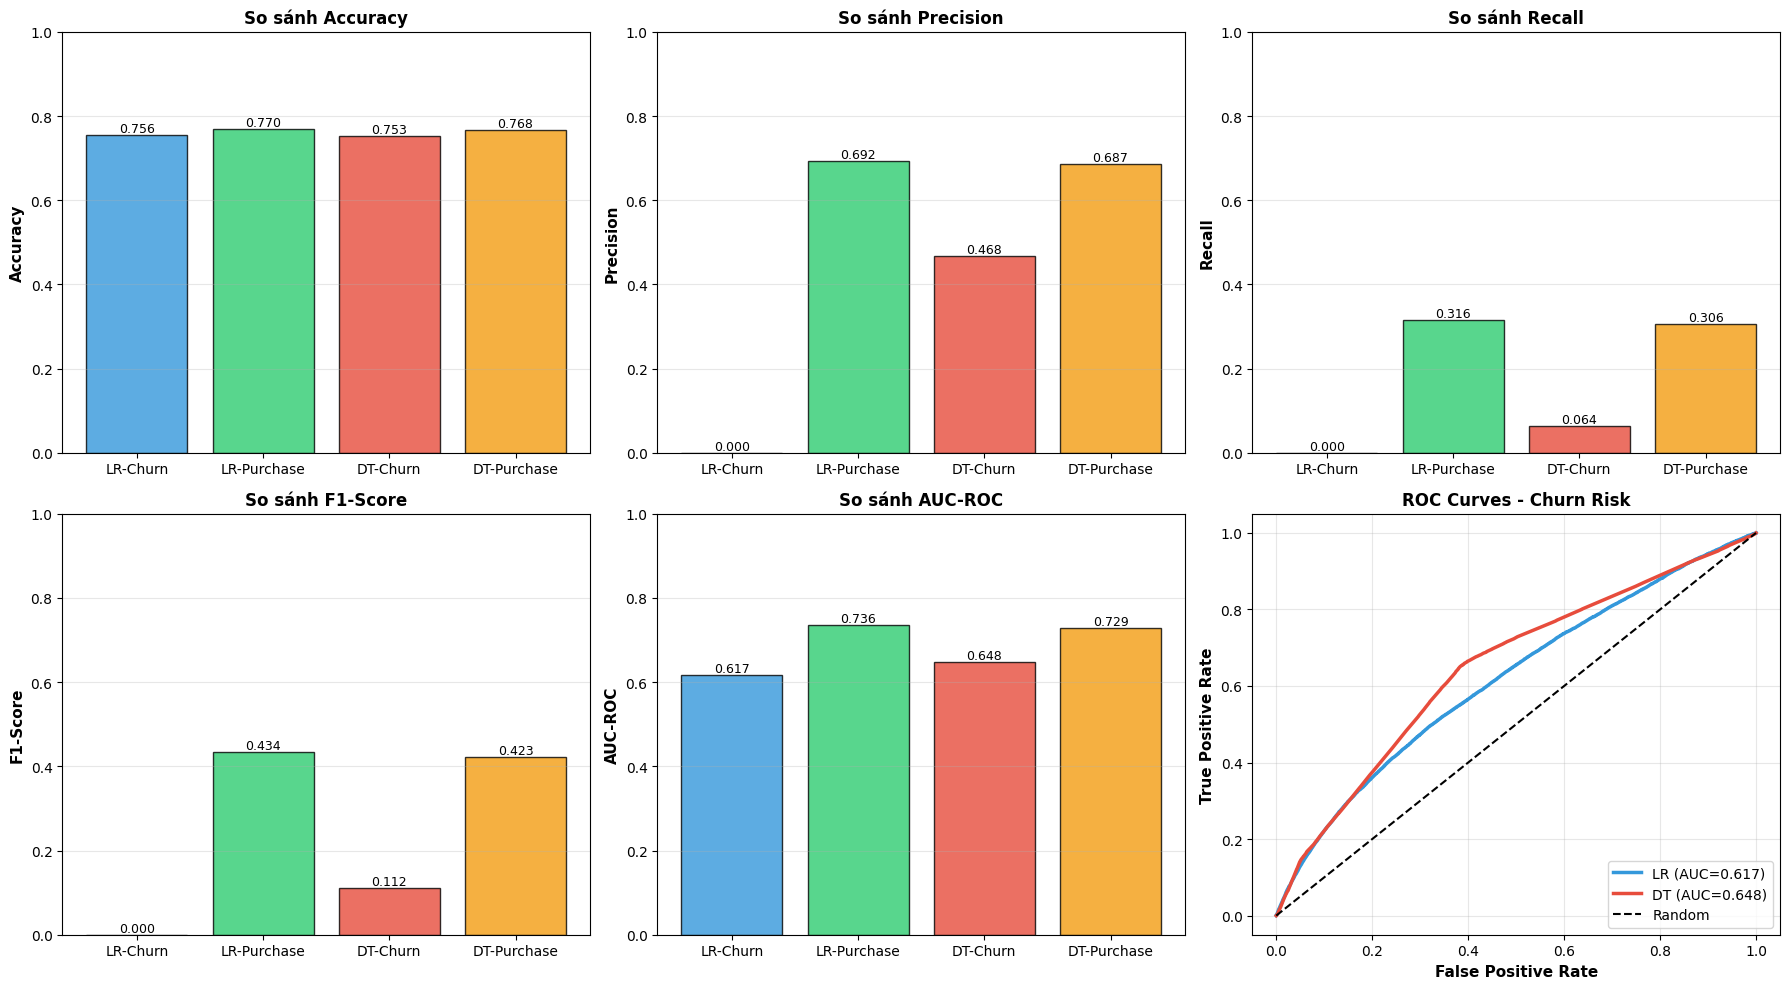

✓ Biểu diễn hoàn thành


In [90]:
### 8.7 Biểu diễn trực quan kết quả mô hình

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. So sánh Accuracy
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
models = ['LR-Churn', 'LR-Purchase', 'DT-Churn', 'DT-Purchase']
colors_model = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    values = [
        df_comparison[df_comparison['Target'] == 'Churn Risk'].iloc[0][metric],
        df_comparison[df_comparison['Target'] == 'Premium Purchased'].iloc[0][metric],
        df_comparison[df_comparison['Target'] == 'Churn Risk'].iloc[1][metric],
        df_comparison[df_comparison['Target'] == 'Premium Purchased'].iloc[1][metric]
    ]
    bars = ax.bar(models, values, color=colors_model, edgecolor='black', alpha=0.8)
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'So sánh {metric}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Thêm giá trị trên các cột
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 6. ROC Curves
ax6 = axes[1, 2]
fpr_lr_c, tpr_lr_c, _ = roc_curve(y_test_c, y_proba_lr_c)
fpr_dt_c, tpr_dt_c, _ = roc_curve(y_test_c, y_proba_dt_c)

ax6.plot(fpr_lr_c, tpr_lr_c, label=f'LR (AUC={lr_c_auc:.3f})', linewidth=2.5, color='#3498db')
ax6.plot(fpr_dt_c, tpr_dt_c, label=f'DT (AUC={dt_c_auc:.3f})', linewidth=2.5, color='#e74c3c')
ax6.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random')
ax6.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax6.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax6.set_title('ROC Curves - Churn Risk', fontsize=12, fontweight='bold')
ax6.legend(loc='lower right')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Biểu diễn hoàn thành")

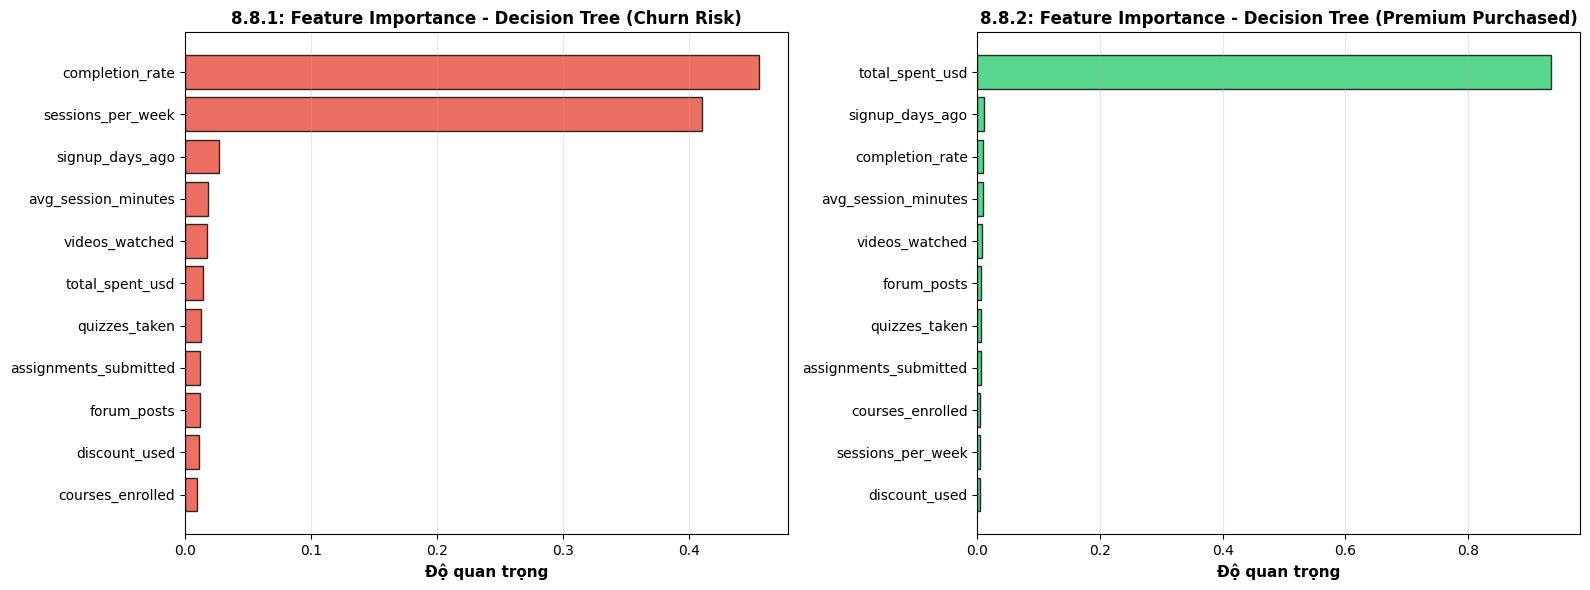

8.8 ĐỘ QUAN TRỌNG ĐẶC TRƯNG (FEATURE IMPORTANCE)

Churn Risk - Top 5 Features:
               Feature  Importance
4      completion_rate    0.455358
1    sessions_per_week    0.410334
8      signup_days_ago    0.026696
0  avg_session_minutes    0.018441
2       videos_watched    0.017457

Premium Purchased - Top 5 Features:
               Feature  Importance
5      total_spent_usd    0.936023
8      signup_days_ago    0.010872
4      completion_rate    0.008663
0  avg_session_minutes    0.008622
2       videos_watched    0.007218


In [91]:
### 8.8 Độ quan trọng đặc trưng - Feature Importance

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Decision Tree - Churn Risk - Feature Importance
feature_imp_c = pd.DataFrame(
    {"Feature": feature_cols, "Importance": dt_churn.feature_importances_}
).sort_values("Importance", ascending=True)

axes[0].barh(
    feature_imp_c["Feature"],
    feature_imp_c["Importance"],
    color="#e74c3c",
    edgecolor="black",
    alpha=0.8,
)
axes[0].set_xlabel("Độ quan trọng", fontsize=11, fontweight="bold")
axes[0].set_title(
    "8.8.1: Feature Importance - Decision Tree (Churn Risk)",
    fontsize=12,
    fontweight="bold",
)
axes[0].grid(True, alpha=0.3, axis="x")

# Decision Tree - Premium Purchased - Feature Importance
feature_imp_p = pd.DataFrame(
    {"Feature": feature_cols, "Importance": dt_purchase.feature_importances_}
).sort_values("Importance", ascending=True)

axes[1].barh(
    feature_imp_p["Feature"],
    feature_imp_p["Importance"],
    color="#2ecc71",
    edgecolor="black",
    alpha=0.8,
)
axes[1].set_xlabel("Độ quan trọng", fontsize=11, fontweight="bold")
axes[1].set_title(
    "8.8.2: Feature Importance - Decision Tree (Premium Purchased)",
    fontsize=12,
    fontweight="bold",
)
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()


print("8.8 ĐỘ QUAN TRỌNG ĐẶC TRƯNG (FEATURE IMPORTANCE)")
print("\nChurn Risk - Top 5 Features:")
print(feature_imp_c.sort_values("Importance", ascending=False).head())
print("\nPremium Purchased - Top 5 Features:")
print(feature_imp_p.sort_values("Importance", ascending=False).head())